# 1. General Problem Set-up

## Import packages

In [95]:
import pandas as pd
import numpy as np

## Import LCA matrices from OpenLCA

In [2]:
A_df = pd.read_csv("data/A.csv", header=None)
B_df = pd.read_csv("data/B.csv", header=None)
C_df = pd.read_csv("data/C.csv", header=None)

# Convert all string-looking numbers to floats
A = A_df.apply(pd.to_numeric, errors='coerce').values
B = B_df.apply(pd.to_numeric, errors='coerce').values
C = C_df.apply(pd.to_numeric, errors='coerce').values

In [3]:
A_index_df = pd.read_csv("data/index_A.csv")
B_index_df = pd.read_csv("data/index_B.csv")
C_index_df = pd.read_csv("data/index_C.csv")

## Removing Transportation (deregionalization)

In [4]:
A_transport_df = pd.read_csv("data/Transportation_A.csv")

In [5]:
# create a dict mapping each provider name to all its indices in A_index_df
mapping = A_index_df.groupby('provider name')['index'].apply(list)

# build a single flat list of all matching indices for the foreground processes
matched_indices_transport = [
    idx
    for name in A_transport_df['provider name']
    if name in mapping
    for idx in mapping[name]
]

In [6]:
import numpy as np

# matched_indices_transport is the list of indices to remove
to_drop = np.array(sorted(set(matched_indices_transport), key=int))

# 1) Remove from A_index_df
mask_keep = ~A_index_df['index'].isin(to_drop)
A_index_df = A_index_df.loc[mask_keep].copy()

# 2) Remove corresponding rows and columns from A
A = np.delete(A, to_drop, axis=0)  # remove rows
A = np.delete(A, to_drop, axis=1)  # remove columns

# 3) Remove the same columns from B (keep rows)
B = np.delete(B, to_drop, axis=1)

# 4) Reset the index column in A_index_df
A_index_df['index'] = np.arange(len(A_index_df), dtype=int)

## Aggregating electricity

In [7]:
A_elec_df = pd.read_csv("data/Electricity_A.csv")

In [8]:
# Inputs assumed:
# A : numeric numpy array (rows x cols)
# A_index_df : DataFrame with columns ["index", "provider name", "flow name", ...]
# A_elec_df : DataFrame with column ["provider name"] listing all electricity providers
# The indices in A_index_df["index"] align with both row and column positions of A.

# 0) Build the set of electricity provider names
elec_names = set(A_elec_df['provider name'].dropna().astype(str).unique())

# 1) Find their indices in A_index_df
elec_idx = A_index_df.loc[A_index_df['provider name'].astype(str).isin(elec_names), 'index'].astype(int).unique()

# 2) Locate the mix row index (must exist)
mix_name = "Electricity Mix (Global)"
mix_rows = A_index_df.loc[A_index_df['provider name'] == mix_name, 'index'].astype(int).unique()
if len(mix_rows) == 0:
    raise ValueError("Electricity Mix (Global) not found in A_index_df['provider name'].")
mix_idx = int(mix_rows[0])

# Ensure the mix row is not purged
elec_idx_set = set(map(int, elec_idx))
elec_idx_wo_mix = sorted(elec_idx_set - {mix_idx})

# 3) Aggregate: add all electricity rows (except the mix row) into the mix row, column-wise
if len(elec_idx_wo_mix) > 0:
    # in case of NaNs
    add_block = np.nansum(A[elec_idx_wo_mix, :], axis=0)
    A[mix_idx, :] = np.nan_to_num(A[mix_idx, :]) + np.nan_to_num(add_block)

# 4) Decide what to drop
rows_to_drop = np.array(elec_idx_wo_mix, dtype=int)            # drop electricity rows except the mix row
cols_to_drop = np.array(elec_idx_wo_mix, dtype=int)            # drop electricity columns except the mix column

# (Optionally also drop the mix COLUMN; keep it if you want to retain that process as a column)
# To ALSO drop the mix column, uncomment the next line:
# cols_to_drop = np.array(sorted(elec_idx_set), dtype=int)

# 5) Remove rows/columns from A and columns from B
if rows_to_drop.size > 0:
    A = np.delete(A, rows_to_drop, axis=0)
if cols_to_drop.size > 0:
    A = np.delete(A, cols_to_drop, axis=1)
    B = np.delete(B, cols_to_drop, axis=1)

# 6) Remove the same rows from A_index_df (only rows; columns in A_index_df are metadata)
if len(elec_idx_wo_mix) > 0:
    keep_mask = ~A_index_df['index'].astype(int).isin(elec_idx_wo_mix)
    A_index_df = A_index_df.loc[keep_mask].copy()

# 7) Reset the "index" column in A_index_df to reflect 0..n-1 after deletions
A_index_df['index'] = np.arange(len(A_index_df), dtype=int)

In [9]:
# Global Electricity Mix for 2025
electricity_mix_df = pd.read_csv("data/electricity_mix.csv")

In [10]:
import numpy as np
import pandas as pd

# --- helpers ---
norm = lambda s: str(s).strip().casefold()

# copies + normalized keys
A_index_df = A_index_df.copy()
electricity_mix_df = electricity_mix_df.copy()

A_index_df["provider_key"] = A_index_df["provider name"].map(norm)
electricity_mix_df["provider_key"] = electricity_mix_df["provider name"].map(norm)

# map: provider_key -> list of row indices in A (these are the *rows*)
row_idx_map = (
    A_index_df.groupby("provider_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# find the *column* indices in A for each target electricity column
def get_col_idx(label: str) -> int:
    key = norm(label)
    arr = A_index_df.loc[A_index_df["provider_key"] == key, "index"].astype(int).values
    if len(arr) == 0:
        raise ValueError(f"'{label}' not found in A_index_df['provider name']")
    return int(arr[0])

col_map = {
    "Fossil Electricity - 2025":      get_col_idx("Fossil Electricity"),
    "Clean Electricity - 2025":       get_col_idx("Clean Electricity"),
    "2025 Energy Mix":                get_col_idx("Electricity Mix (Global)"),
}

# ensure numeric inputs; keep NaN to skip writes cleanly
for src_col in list(col_map.keys()):
    if src_col not in electricity_mix_df.columns:
        raise ValueError(f"Source column '{src_col}' not found in electricity_mix_df")
    electricity_mix_df[src_col] = pd.to_numeric(electricity_mix_df[src_col], errors="coerce")

# --- assign values into A ---
for _, row in electricity_mix_df.iterrows():
    pkey = row["provider_key"]
    rows = row_idx_map.get(pkey, [])
    if not rows:
        continue  # provider not in A_index_df rows — skip

    for src_col, target_col_idx in col_map.items():
        val = row[src_col]
        if pd.isna(val):
            continue  # nothing to write
        v = float(val)
        for r in rows:
            A[int(r), target_col_idx] = v


## Quality Scenario (for recycled material from mechanical)

In [11]:
quality_scenarios_df = pd.read_csv("data/quality_scenarios.csv")

In [12]:
# Assumes the following are already in memory:
# - quality_scenarios_df  with columns: "Recycling Process", "Substitutable Virgin Process", "S1 - no limit"
# - A_index_df            with columns: "Provider name", "Index"
# - A                     as a NumPy array (your A-matrix)

# Normalize helper (case-insensitive, trim spaces)
_norm = lambda s: str(s).strip().casefold()

# Build name -> index map from A_index_df
# If A_index_df['Index'] is 1-based, uncomment the "- 1" line below instead.
name_to_idx = {
    _norm(p): int(i)
    for p, i in zip(A_index_df["provider name"], A_index_df["index"])
    # for p, i in zip(A_index_df["Provider name"], A_index_df["Index"] - 1)  # <- use this if indices are 1-based
}

# Map processes to A indices
col_idx = quality_scenarios_df["Recycling Process"].astype(str).map(_norm).map(name_to_idx)
row_idx = quality_scenarios_df["Substitutable Virgin Process"].astype(str).map(_norm).map(name_to_idx)

# Save the pair (row, col) to the "Index" column
quality_scenarios_df["index"] = list(zip(row_idx, col_idx))

# Pull values to write
vals = pd.to_numeric(quality_scenarios_df["S1 - no limit"], errors="coerce")

# Only update where both indices and value are valid
mask = row_idx.notna() & col_idx.notna() & vals.notna()
rows = row_idx[mask].astype(int).to_numpy()
cols = col_idx[mask].astype(int).to_numpy()
v    = vals[mask].to_numpy(dtype=float)

# Write into A at (row, col)
A[rows, cols] = v

# Optional diagnostics:
# print("Updated entries:", mask.sum())
# print("Unmatched Recycling Process:", quality_scenarios_df.loc[col_idx.isna(), "Recycling Process"].drop_duplicates().tolist()[:10])
# print("Unmatched Substitutable Virgin Process:", quality_scenarios_df.loc[row_idx.isna(), "Substitutable Virgin Process"].drop_duplicates().tolist()[:10])


In [13]:
A[int(A_index_df.loc[A_index_df["provider name"]=="Polyethylene, high density, HDPE, virgin resin, food non-bottle grade","index"].iloc[0]),
  int(A_index_df.loc[A_index_df["provider name"]=="Mechanical Recycling, HDPE Other Food Rigid (Flakes)","index"].iloc[0])]

1.0

## Identifying background flows for cost calculation

In [14]:
A_foreground_df = pd.read_csv("data/Foreground_A.csv")

In [15]:
import numpy as np
import pandas as pd

# Helper for consistent comparison
norm = lambda s: str(s).strip().casefold()

# Normalize keys
A_index_df = A_index_df.copy()
A_foreground_df = A_foreground_df.copy()
A_index_df['provider_key'] = A_index_df['provider name'].map(norm)
A_foreground_df['provider_key'] = A_foreground_df['provider name'].map(norm)

# Build mapping from provider -> indices
idx_map = (
    A_index_df
    .groupby('provider_key')['index']
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# Foreground indices (to exclude later)
matched_indices = sorted({
    idx
    for key in A_foreground_df['provider_key'].unique()
    for idx in idx_map.get(key, [])
})

# Example: build all_nonzero from the numeric matrix A
# (take all row indices with nonzero entries across the columns in matched_indices)
all_nonzero = set()
for col in matched_indices:
    all_nonzero.update(np.nonzero(A[:, col])[0])

# Remove overlap
foreground_set = set(matched_indices)
all_nonzero_set = {int(x) for x in all_nonzero}
filtered_nonzero_rows = sorted(all_nonzero_set - foreground_set)


In [16]:
result_df = A_index_df[A_index_df['index'].isin(filtered_nonzero_rows)].copy()

In [17]:
result_df.to_csv('filtered_nonzero_rows_with_names.csv', index=False)

## Importing financial data for cost calculation

In [18]:
financial_df = pd.read_csv("data/Financial.csv")

# 2. Static Analysis and Optimization

## 2.1. Base Case (Linear fossil economy in 2025 without carbon capture and microplastic treatment)

### Electricity Mix

In [19]:
# Global Electricity Mix for 2025
electricity_mix_df = pd.read_csv("data/electricity_mix.csv")

In [20]:
import numpy as np
import pandas as pd

# --- helpers ---
norm = lambda s: str(s).strip().casefold()

# copies + normalized keys
A_index_df = A_index_df.copy()
electricity_mix_df = electricity_mix_df.copy()

A_index_df["provider_key"] = A_index_df["provider name"].map(norm)
electricity_mix_df["provider_key"] = electricity_mix_df["provider name"].map(norm)

# map: provider_key -> list of row indices in A (these are the *rows*)
row_idx_map = (
    A_index_df.groupby("provider_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# find the *column* indices in A for each target electricity column
def get_col_idx(label: str) -> int:
    key = norm(label)
    arr = A_index_df.loc[A_index_df["provider_key"] == key, "index"].astype(int).values
    if len(arr) == 0:
        raise ValueError(f"'{label}' not found in A_index_df['provider name']")
    return int(arr[0])

col_map = {
    "Fossil Electricity - 2025":      get_col_idx("Fossil Electricity"),
    "Clean Electricity - 2025":       get_col_idx("Clean Electricity"),
    "2025 Energy Mix":                get_col_idx("Electricity Mix (Global)"),
}

# ensure numeric inputs; keep NaN to skip writes cleanly
for src_col in list(col_map.keys()):
    if src_col not in electricity_mix_df.columns:
        raise ValueError(f"Source column '{src_col}' not found in electricity_mix_df")
    electricity_mix_df[src_col] = pd.to_numeric(electricity_mix_df[src_col], errors="coerce")

# --- assign values into A ---
for _, row in electricity_mix_df.iterrows():
    pkey = row["provider_key"]
    rows = row_idx_map.get(pkey, [])
    if not rows:
        continue  # provider not in A_index_df rows — skip

    for src_col, target_col_idx in col_map.items():
        val = row[src_col]
        if pd.isna(val):
            continue  # nothing to write
        v = float(val)
        for r in rows:
            A[int(r), target_col_idx] = v


In [21]:
A[int(A_index_df.loc[A_index_df["provider name"]=="Electricity, hydropower (life cycle)","index"].iloc[0]),
  int(A_index_df.loc[A_index_df["provider name"]=="Clean Electricity","index"].iloc[0])]

-0.35

### Collection and Sorting

In [22]:
packaging_types_df = pd.read_csv("data/packaging_types.csv")
collection_recyclate_df = pd.read_csv("data/collection_Recyclate.csv")
collection_msw_df = pd.read_csv("data/collection_MSW.csv")

In [23]:
import numpy as np
import pandas as pd
import re

# ---- exact-key matcher (case/space insensitive, keeps stage prefixes) ----
ekey = lambda s: str(s).strip().casefold()

# ---- copies + normalized keys ----
A_index_df = A_index_df.copy()
packaging_types_df = packaging_types_df.copy()
collection_msw_df = collection_msw_df.copy()

A_index_df["prov_exact"]         = A_index_df["provider name"].map(ekey)
packaging_types_df["prov_exact"] = packaging_types_df["provider name"].map(ekey)
collection_msw_df["prov_exact"]  = collection_msw_df["provider name"].map(ekey)

# If you know the 3 mapping columns, set them here, e.g.:
# mapping_cols = ["dest_1", "dest_2", "dest_3"]
# Otherwise, auto-detect up to 3 string columns besides 'provider name'
mapping_cols = [c for c in packaging_types_df.columns
                if c not in ("provider name", "prov_exact")
                and pd.api.types.is_string_dtype(packaging_types_df[c])][:3]
if not mapping_cols:
    raise ValueError("Couldn't detect mapping columns; please set 'mapping_cols' explicitly.")

# Normalize destination columns
for col in mapping_cols:
    packaging_types_df[col + "_exact"] = packaging_types_df[col].map(ekey)

# provider name -> list of integer indices in A (rows/cols)
idx_map_exact = (
    A_index_df.groupby("prov_exact")["index"]
              .apply(lambda s: list(map(int, s)))
              .to_dict()
)

# "Use & Collection" column index
use_col = int(A_index_df.loc[A_index_df["provider name"]=="Use & Collection","index"].iloc[0])

# ---- X: abs(A[row, use_col]) per packaging provider (exact match) ----
X_by_src = {}
for k in packaging_types_df["prov_exact"].dropna().unique():
    rows = idx_map_exact.get(k, [])
    if rows:
        r0 = int(rows[0])  # if multiple rows per provider, change to sum/mean if needed
        X_by_src[k] = abs(float(A[r0, use_col]))

# ---- Y: MSW "Linear Economy" per provider (exact match) ----
Y_by_key = (collection_msw_df.dropna(subset=["prov_exact"])
            .groupby("prov_exact")["Linear Economy"]
            .first()
            .to_dict())

# ---- zero out destination cells we're going to rewrite (avoid accumulation on reruns) ----
dest_rows = set()
for _, row in packaging_types_df.iterrows():
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if dk in idx_map_exact:
            dest_rows.update(idx_map_exact[dk])
if dest_rows:
    A[list(dest_rows), use_col] = 0.0

# ---- assign: A[row, use_col] += X * Y for each mapped destination (exact match) ----
for _, row in packaging_types_df.iterrows():
    src_k = row["prov_exact"]
    X     = X_by_src.get(src_k)
    if X is None:
        continue
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if not dk:
            continue
        Y = Y_by_key.get(dk)
        if Y is None or pd.isna(Y):
            continue
        contrib = float(abs(X) * float(Y))
        for r in idx_map_exact.get(dk, []):
            A[int(r), use_col] += contrib

In [24]:
A[int(A_index_df.loc[A_index_df["provider name"]=="Disposal, Multi-material Food Bottles","index"].iloc[0]),
  int(A_index_df.loc[A_index_df["provider name"]=="Use & Collection","index"].iloc[0])]

0.021840000000000002

In [25]:
# --- Recyclate pass: X * Y_recyclate added into A[:, use_col] ---

collection_recyclate_df = collection_recyclate_df.copy()
collection_recyclate_df["prov_exact"] = collection_recyclate_df["provider name"].map(ekey)

# Y from recyclate
Y_rec_by_key = (
    collection_recyclate_df.dropna(subset=["prov_exact"])
    .groupby("prov_exact")["Linear Economy"]
    .first()    # change to sum()/mean() if needed
    .to_dict()
)

# Optionally clear destination cells before this pass (default = keep MSW values and add recyclate)
reset_dest = False
if reset_dest:
    rec_dest_rows = set()
    for _, row in packaging_types_df.iterrows():
        for col in mapping_cols:
            dk = row.get(col + "_exact", None)
            rec_dest_rows.update(idx_map_exact.get(dk, []))
    if rec_dest_rows:
        A[np.array(sorted(rec_dest_rows), dtype=int), use_col] = 0.0

# Write: A[row, use_col] += X * Y_recyclate
for _, row in packaging_types_df.iterrows():
    src_k = row["prov_exact"]
    X = X_by_src.get(src_k)
    if X is None:
        continue
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if not dk:
            continue
        Y = Y_rec_by_key.get(dk)
        if Y is None or pd.isna(Y):
            continue
        contrib = float(abs(X) * float(Y))
        for r in idx_map_exact.get(dk, []):
            A[int(r), use_col] += contrib

In [26]:
A[int(A_index_df.loc[A_index_df["provider name"]=="Low-tech Sorting, Collected HDPE Drinking Bottles","index"].iloc[0]),
  int(A_index_df.loc[A_index_df["provider name"]=="Use & Collection","index"].iloc[0])]

0.0

### Monomers

In [22]:
monomers_decisions_df = pd.read_csv("data/monomers_decisions.csv")

In [23]:
import numpy as np
import pandas as pd

# ---- helper: normalize names for reliable matching ----
ekey = lambda s: str(s).strip().casefold()

# ---- defensive copies + normalized keys ----
A_index_df = A_index_df.copy()
monomers_decisions_df = monomers_decisions_df.copy()

A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
monomers_decisions_df["col_key"]  = monomers_decisions_df["Provider name"].map(ekey)
monomers_decisions_df["row_key"]  = monomers_decisions_df["Input parameters names"].map(ekey)

# provider key -> list of integer indices in A (rows/cols)
idx_map = (
    A_index_df.groupby("prov_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# ensure "Linear Economy" is numeric
monomers_decisions_df["Linear Economy"] = pd.to_numeric(
    monomers_decisions_df["Linear Economy"], errors="coerce"
)

# ---- apply updates: for each row in decisions, scale A[row_idx, col_idx] *= X ----
n_pairs = 0
skipped = 0

for _, drow in monomers_decisions_df.iterrows():
    x = drow["Linear Economy"]
    if pd.isna(x):
        skipped += 1
        continue

    row_idxs = idx_map.get(drow["row_key"], [])
    col_idxs = idx_map.get(drow["col_key"], [])

    if not row_idxs or not col_idxs:
        skipped += 1
        continue

    # multiply all combinations (row, col) by X
    for ri in row_idxs:
        for ci in col_idxs:
            A[int(ri), int(ci)] = np.nan_to_num(A[int(ri), int(ci)]) * float(x)
            n_pairs += 1

In [24]:
A[int(A_index_df.loc[A_index_df["provider name"]=="Ethylene production, fossil, steam cracker","index"].iloc[0]),
  int(A_index_df.loc[A_index_df["provider name"]=="Ethylene","index"].iloc[0])]

-1.0

### Carbon Capture

In [25]:
carbon_capture_decisions_df = pd.read_csv("data/carbon_capture_decisions.csv")

In [26]:
import numpy as np
import pandas as pd

# normalize for reliable matching
ekey = lambda s: str(s).strip().casefold()

# copies + keys
A_index_df = A_index_df.copy()
carbon_capture_decisions_df = carbon_capture_decisions_df.copy()

A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
carbon_capture_decisions_df["col_key"] = carbon_capture_decisions_df["Provider name"].map(ekey)
carbon_capture_decisions_df["row_key"] = carbon_capture_decisions_df["Input parameters names"].map(ekey)

# provider key -> list of integer indices (row/col) in A
idx_map = (
    A_index_df.groupby("prov_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# ensure numeric X
carbon_capture_decisions_df["Linear Economy"] = pd.to_numeric(
    carbon_capture_decisions_df["Linear Economy"], errors="coerce"
)

# apply: for each decision row, A[row, col] *= X
n_pairs = 0
skipped = 0

for _, d in carbon_capture_decisions_df.iterrows():
    X = d["Linear Economy"]
    if pd.isna(X):
        skipped += 1
        continue

    row_idxs = idx_map.get(d["row_key"], [])
    col_idxs = idx_map.get(d["col_key"], [])

    if not row_idxs or not col_idxs:
        skipped += 1
        continue

    for ri in row_idxs:
        for ci in col_idxs:
            A[int(ri), int(ci)] = np.nan_to_num(A[int(ri), int(ci)]) * float(X)
            n_pairs += 1

In [27]:
A[int(A_index_df.loc[A_index_df["provider name"]=="Plastic Incineration CO2 to the atmosphere","index"].iloc[0]),
  int(A_index_df.loc[A_index_df["provider name"]=="Plastic Incineration CO2","index"].iloc[0])]

1.0

### microplastics treatment

In [33]:
microplastics_decisions_df = pd.read_csv("data/microplastics_decisions.csv")

In [34]:
import numpy as np
import pandas as pd

# normalizer
ekey = lambda s: str(s).strip().casefold()

# copies + normalized keys
A_index_df = A_index_df.copy()
microplastics_decisions_df = microplastics_decisions_df.copy()

A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
microplastics_decisions_df["col_key"] = microplastics_decisions_df["Provider name"].map(ekey)
microplastics_decisions_df["row_key"] = microplastics_decisions_df["Input parameters names"].map(ekey)

# provider key -> list of integer indices in A (rows/cols)
idx_map = (
    A_index_df.groupby("prov_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# ensure numeric decision value
microplastics_decisions_df["No WWT Filtration"] = pd.to_numeric(
    microplastics_decisions_df["No WWT Filtration"], errors="coerce"
)

# apply decisions: A[row, col] *= value
n_pairs = 0
skipped = 0

for _, d in microplastics_decisions_df.iterrows():
    x = d["No WWT Filtration"]
    if pd.isna(x):
        skipped += 1
        continue

    row_idxs = idx_map.get(d["row_key"], [])
    col_idxs = idx_map.get(d["col_key"], [])

    if not row_idxs or not col_idxs:
        skipped += 1
        continue

    for ri in row_idxs:
        for ci in col_idxs:
            A[int(ri), int(ci)] = np.nan_to_num(A[int(ri), int(ci)]) * float(x)
            n_pairs += 1

In [35]:
A[int(A_index_df.loc[A_index_df["provider name"]=="Plastic Incineration CO2 to the atmosphere","index"].iloc[0]),
  int(A_index_df.loc[A_index_df["provider name"]=="Plastic Incineration CO2","index"].iloc[0])]

1.0

### LCA/TEA Calculations

In [36]:
# LCA Calculations
packaging_demand_2025 = 4.29e+11 #429 MMT
f = np.zeros(len(A))
f[0] = packaging_demand_2025
s = np.linalg.solve(A, f)
g = B@s
phi = C@g
phi_normalized = phi/packaging_demand_2025

In [37]:
phi_normalized

array([3.47584858e+00, 8.88848258e-08, 1.04594237e-01])

In [38]:
# LCA Hotspots
# Impact per provider for category 0
CB = C @ B                                  # (n_impacts × n_providers)
contrib = s * CB[0, :]                      # contribution per provider
total_phi0 = contrib.sum()

# Use provider names from A_index_df
df = pd.DataFrame({
    "provider_name": A_index_df["provider name"].values,  # adjust column name if needed
    "contribution": contrib
})
df["share_%"] = 100 * df["contribution"] / total_phi0

# Top 10 contributors (by signed value)
top10 = df.sort_values("contribution", ascending=False).head(10)
print("\nTop 10 contributors to phi[0]:")
print(top10.reset_index(drop=True))

# If you want absolute-value ranking (credits vs burdens):
top10_abs = df.iloc[df["contribution"].abs().sort_values(ascending=False).index].head(10)
print("\nTop 10 contributors to phi[x] (absolute):")
print(top10_abs.reset_index(drop=True))


Top 10 contributors to phi[0]:
                                       provider_name  contribution    share_%
0                     Electricity, coal (life cycle)  2.128320e+11  14.273117
1                Steam Cracker CO2 to the atmosphere  2.054939e+11  13.781005
2         Plastic Incineration CO2 to the atmosphere  1.908820e+11  12.801086
3  Natural gas, combusted in industrial boiler, a...  1.712721e+11  11.485992
4        Natural gas, combusted in industrial boiler  9.676839e+10   6.489562
5              Electricity, natural gas (life cycle)  6.687860e+10   4.485068
6                    Petroleum refining, at refinery  5.845680e+10   3.920278
7                                   Open Burning, PP  5.443242e+10   3.650392
8                                  Open Burning, PET  4.452687e+10   2.986098
9          Crude oil, on-shore import, at extraction  4.341765e+10   2.911711

Top 10 contributors to phi[x] (absolute):
                                       provider_name  contribution 

In [39]:
import numpy as np
import pandas as pd

ekey = lambda s: str(s).strip().casefold()

# normalize and build index map
A_index_df = A_index_df.copy()
A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
idx_map = A_index_df.groupby("prov_key")["index"].apply(lambda s: list(map(int, s))).to_dict()

# foreground → column indices
A_foreground_df = A_foreground_df.copy()
A_foreground_df["prov_key"] = A_foreground_df["provider name"].map(ekey)
fg_cols_by_name = {}
for name, key in zip(A_foreground_df["provider name"], A_foreground_df["prov_key"]):
    cols = idx_map.get(key, [])
    if cols:
        fg_cols_by_name.setdefault(name, []).extend(int(c) for c in cols)

# financial rows → row indices with per-unit cost
financial_df = financial_df.copy()
if pd.api.types.is_numeric_dtype(financial_df["LCI Column Index"]):
    financial_df["row_index"] = financial_df["LCI Column Index"].astype(int)
else:
    financial_df["row_key"] = financial_df["LCI Column Index"].map(ekey)
    financial_df["row_index"] = financial_df["row_key"].map(lambda k: idx_map.get(k, [None])[0])

financial_df["Value"] = pd.to_numeric(financial_df["Value"], errors="coerce")
fin_rows = financial_df.dropna(subset=["row_index", "Value"]).copy()
fin_rows["row_index"] = fin_rows["row_index"].astype(int)
cost_by_row = fin_rows.groupby("row_index")["Value"].sum().to_dict()

# ABS versions of A and s
A_abs = np.abs(A)
s_abs = np.abs(s)

# compute cost per foreground process
cost_by_foreground = {}
for fg_name, col_list in fg_cols_by_name.items():
    total_cost_fg = 0.0
    for c in set(col_list):
        sc = float(s_abs[c]) if np.isfinite(s_abs[c]) else 0.0
        if sc == 0.0:
            continue
        for r, unit_cost in cost_by_row.items():
            a_val = float(A_abs[r, c]) if np.isfinite(A_abs[r, c]) else 0.0
            if a_val != 0.0 and unit_cost is not None:
                total_cost_fg += a_val * sc * float(unit_cost)
    cost_by_foreground[fg_name] = total_cost_fg

total_variable_cost = sum(cost_by_foreground.values())
# print formatted in million dollars
print("Total variable operating cost:",
      f"${total_variable_cost/1e9:,.2f} Billion")

Total variable operating cost: $438.37 Billion


In [41]:
total_variable_cost/packaging_demand_2025

1.0218333293526296

In [43]:
# sort the processes by cost (descending)
top10 = sorted(cost_by_foreground.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 most expensive foreground processes:")
for name, val in top10:
    print(f"{name}: ${val/1e9:,.2f} Billion")

Top 10 most expensive foreground processes:
Hydrocarbon feedstock production for use in steam cracker: $141.02 Billion
Xylenes, mixed, produced from naphtha, at plant, kg: $46.36 Billion
PET Drinking Bottles: $31.35 Billion
PP Other Food Rigid: $24.26 Billion
Ethanol, denatured, forest residues, thermochem: $17.09 Billion
Ethylene glycol, fossil: $11.35 Billion
Polyethylene, low-density, LDPE, virgin resin, food grade: $10.74 Billion
HDPE Non-food Bottles: $9.65 Billion
Purified terephthalic acid, PTA, fossil: $9.58 Billion
Propylene production, fossil, steam cracker: $7.96 Billion


In [44]:
biodiversity_breakdown_df = pd.read_csv("data/biodiversity_breakdown.csv")

In [45]:
import numpy as np
import pandas as pd

# ---- Inputs assumed ----
# C: (n_impacts x n_flows) numpy array
# B: (n_flows x n_procs)   numpy array
# s: (n_procs,)            numpy array
# B_index_df: columns ["index" (int), "flow name" (str)]
# biodiversity_breakdown_df: columns ["flow name", "microplastic", "macroplastic"]

# 1) Build a direct mapping from exact flow name -> flow index (column in C, row in B)
flow_idx_map = dict(zip(B_index_df["flow name"], B_index_df["index"].astype(int)))

# 2) Keep only rows whose flow name exists in the map (exact match)
bd_sub = biodiversity_breakdown_df[biodiversity_breakdown_df["flow name"].isin(flow_idx_map)].copy()

# 3) Indices for those flows, in the same order as bd_sub
flow_indices = bd_sub["flow name"].map(flow_idx_map).astype(int).to_numpy()

# 4) Characterization factors (ensure numeric; NaN -> 0)
micro_vals = pd.to_numeric(bd_sub["microplastic"], errors="coerce").fillna(0.0).to_numpy()
macro_vals = pd.to_numeric(bd_sub["macroplastic"], errors="coerce").fillna(0.0).to_numpy()

# 5) Create C variants and overwrite the SECOND row (index 1) at those columns
row_phi1 = 1
C_micro = C.copy()
C_macro = C.copy()
C_micro[row_phi1, flow_indices] = micro_vals
C_macro[row_phi1, flow_indices] = macro_vals

# 6) Compute phi = C @ (B @ s), then extract phi[1]
inventory = B @ s  # shape (n_flows,)
phi_micro = C_micro @ inventory
phi_macro = C_macro @ inventory

phi1_micro = float(phi_micro[row_phi1])
phi1_macro = float(phi_macro[row_phi1])




In [46]:
print("Marine biodiversity loss due to microplastics (# of potentialy damaged species):", phi1_micro)
print("Marine biodiversity loss due to macroplastics (# of potentialy damaged species):", phi1_macro)
print("Marine biodiversity loss (# of potentialy damaged species):", phi[1])
print("Human health impacts due to plastic combustion (Disability-Adjusted Life Year (DALY)) ", phi[2])
print("Global Warming Potential (kg CO2 eq.)", phi[0])

Marine biodiversity loss due to microplastics (# of potentialy damaged species): 38131.57658287657
Marine biodiversity loss due to macroplastics (# of potentialy damaged species): 0.01367274968422574
Marine biodiversity loss (# of potentialy damaged species): 38131.59025562625
Human health impacts due to plastic combustion (Disability-Adjusted Life Year (DALY))  44870927522.88262
Global Warming Potential (kg CO2 eq.) 1491139040230.6328


In [46]:
import numpy as np
import pandas as pd

# Assumes you already have: C (n_impacts x n_flows), B (n_flows x n_procs), s (n_procs,)
# B_index_df: columns ["index" (int), "flow name" (str)]
# biodiversity_breakdown_df: columns ["flow name", "microplastic_direct", "microplastic_degradation"]

# 1) Exact mapping: flow name -> flow index
flow_idx_map = dict(zip(B_index_df["flow name"], B_index_df["index"].astype(int)))

# 2) Keep only rows whose flow name exists in B_index_df
bd_sub = biodiversity_breakdown_df[
    biodiversity_breakdown_df["flow name"].isin(flow_idx_map)
].copy()

# 3) Flow indices in the same order as bd_sub
flow_indices = bd_sub["flow name"].map(flow_idx_map).astype(int).to_numpy()

# 4) New CF vectors (ensure numeric; NaN -> 0)
mp_direct_vals = pd.to_numeric(bd_sub["microplastic-direct"], errors="coerce").fillna(0.0).to_numpy()
mp_degrad_vals = pd.to_numeric(bd_sub["microplastic-degradation"], errors="coerce").fillna(0.0).to_numpy()

# 5) Create C variants and overwrite the SECOND row (index 1) at those columns
row_phi1 = 1
C_micro_direct = C.copy()
C_micro_degrad = C.copy()

C_micro_direct[row_phi1, flow_indices] = mp_direct_vals
C_micro_degrad[row_phi1, flow_indices] = mp_degrad_vals

# 6) Compute phi = C @ (B @ s), then extract phi[1] for each
inventory = B @ s  # shape (n_flows,)

phi_micro_direct  = C_micro_direct  @ inventory
phi_micro_degrad  = C_micro_degrad  @ inventory

phi1_micro_direct = float(phi_micro_direct[row_phi1])
phi1_micro_degrad = float(phi_micro_degrad[row_phi1])

print("Marine biodiversity loss due to microplastics (direct - pellets mishandling):",     phi1_micro_direct)
print("Marine biodiversity loss due to microplastics (degradation):", phi1_micro_degrad)

Marine biodiversity loss due to microplastics (direct - pellets mishandling): 741.697996906315
Marine biodiversity loss due to microplastics (degradation): 26300.15673956759


In [47]:
plastic_flows_df = pd.read_csv("data/plastic_flows.csv")

In [48]:
import numpy as np
import pandas as pd

# Assumes:
# B (n_flows x n_procs), s (n_procs,), B_index_df (with ["index","flow name"])
# plastic_flows_df: ["flow name", plus one or more scenario columns with 0/1 flags]

# 1) Map flow names -> row indices in B
flow_to_idx = dict(zip(B_index_df["flow name"], B_index_df["index"].astype(int)))

# 2) Keep only flows that exist in B_index_df
pf = plastic_flows_df.copy()
pf = pf[pf["flow name"].isin(flow_to_idx)].copy()
pf["row_index"] = pf["flow name"].map(flow_to_idx).astype(int)

# 3) Inventory vector g = B @ s
g = B @ s   # shape (n_flows,)

# 4) Detect scenario columns (all except "flow name" and "row_index")
scenario_cols = [c for c in pf.columns if c not in ["flow name", "row_index"]]

# 5) Compute sum of g for each scenario
g_sums = {}
for sc in scenario_cols:
    enable_mask = pd.to_numeric(pf[sc], errors="coerce").fillna(0).astype(int).to_numpy()
    rows = pf["row_index"].to_numpy()
    total_kg = float(np.sum(g[rows] * enable_mask))  # kg
    g_sums[sc] = total_kg / 1e9  # convert to million metric tons

# 6) Display results
print("Total generated amounts (Million metric tons) for each scenario:")
for sc, val in g_sums.items():
    print(f"{sc}: {val:,.2f} MMT")

Total generated amounts (Million metric tons) for each scenario:
microplastic_enable: 12.43 MMT
macroplastic_enable: 12.01 MMT
microplastic_direct_enable: 0.42 MMT
microplastic_degradation_enable: 12.01 MMT


In [49]:
import numpy as np
import pandas as pd
import re

# Assumes:
# B (n_flows x n_procs), s (n_procs,), A_index_df (["index","provider name"]),
# B_index_df (["index","flow name"]), plastic_flows_df (["flow name", ...macro... flags])

# 1) Get the Use & Collection process column index
use_col = int(
    A_index_df.loc[A_index_df["provider name"] == "Use & Collection", "index"].iloc[0]
)

# 2) Inventory from Use & Collection only
#    (contribution of that one process to each flow)
g_use = B[:, use_col] * float(s[use_col])

# 3) Map exact flow names -> row indices in B
flow_to_idx = dict(zip(B_index_df["flow name"], B_index_df["index"].astype(int)))

# 4) Align plastic_flows_df to B rows
pf = plastic_flows_df.copy()
pf = pf[pf["flow name"].isin(flow_to_idx)].copy()
pf["row_index"] = pf["flow name"].map(flow_to_idx).astype(int)

# 5) Detect macro scenario columns (flexible: any column name containing "macro")
id_cols = {"flow name", "row_index"}
macro_cols = [c for c in pf.columns
              if c not in id_cols and re.search(r"macro", str(c), flags=re.I)]

if not macro_cols:
    raise ValueError("No macro scenario columns found in plastic_flows_df. "
                     "Add columns like 'macroplastic_enable', 'macro_litter_enable', or 'macro_mismanage_enable' with 0/1 flags.")

# 6) Sum g_use over enabled flows for each macro scenario, in MMT
macro_sums_mmt = {}
rows = pf["row_index"].to_numpy()
for col in macro_cols:
    enable_mask = pd.to_numeric(pf[col], errors="coerce").fillna(0).astype(int).to_numpy()
    total_kg = float(np.sum(g_use[rows] * enable_mask))     # sum only enabled flows
    macro_sums_mmt[col] = total_kg / 1e9                    # kg -> Million metric tons

# 7) Pretty print
print("Macroplastics from Use & Collection only (Million metric tons):")
for col in macro_cols:
    print(f"{col}: {macro_sums_mmt[col]:,.2f} MMT")

Macroplastics from Use & Collection only (Million metric tons):
macroplastic_enable: 10.30 MMT


In [50]:
ghg_grouping_df = pd.read_csv("data/GHG_grouping.csv")

In [51]:
import pandas as pd
import numpy as np

# ---- baseline hotspot setup ----
CB = C @ B                                  # (n_impacts × n_providers)
contrib = s * CB[0, :]                      # contribution per provider
total_phi0 = contrib.sum()

df = pd.DataFrame({
    "provider_name": A_index_df["provider name"].values,
    "contribution": contrib
})
df["share_%"] = 100 * df["contribution"] / total_phi0

# ---- grouping across multiple columns with precedence ----
group_cols = ["Open Burning EOL", "Fossil Electricity", "Fossil Heat"]  # left wins on conflicts

# Build case-insensitive mapping: provider -> group label
name_to_group = {}
# canonicalize provider names in df once
df["_key"] = df["provider_name"].astype(str).str.strip().str.casefold()

for col in group_cols:
    if col not in ghg_grouping_df.columns:
        continue
    col_vals = (
        ghg_grouping_df[col]
        .dropna()
        .astype(str)
        .str.strip()
        .replace({"": np.nan})
        .dropna()
        .str.casefold()
        .unique()
    )
    for nkey in col_vals:
        name_to_group.setdefault(nkey, col)

# Apply mapping; fall back to original provider when not grouped
df["grouped_name"] = df["_key"].map(lambda k: name_to_group.get(k, None))
# If not grouped, keep the original display name
df["grouped_name"] = np.where(df["grouped_name"].isna(), df["provider_name"], df["grouped_name"])

# Aggregate
df_grouped = (
    df.groupby("grouped_name", as_index=False)
      .agg(contribution=("contribution", "sum"))
)
df_grouped["share_%"] = 100 * df_grouped["contribution"] / total_phi0

# Rankings
top10 = df_grouped.sort_values("contribution", ascending=False).head(10)
print("\nTop 10 contributors to phi[0] (with grouping):")
print(top10.reset_index(drop=True))

top10_abs = df_grouped.iloc[df_grouped["contribution"].abs().sort_values(ascending=False).index].head(10)
print("\nTop 10 contributors to phi[0] (absolute, with grouping):")
print(top10_abs.reset_index(drop=True))



Top 10 contributors to phi[0] (with grouping):
                                        grouped_name  contribution    share_%
0                                 Fossil Electricity  4.914484e+11  40.068429
1                                        Fossil Heat  2.747486e+11  22.400611
2                Steam Cracker CO2 to the atmosphere  9.652498e+10   7.869806
3                                   Open Burning EOL  5.078074e+10   4.140220
4         Plastic Incineration CO2 to the atmosphere  4.902968e+10   3.997454
5                     Pyrolysis, PP Other Food Rigid  2.827973e+10   2.305683
6  Pyrolysis, LDPE Food Packaging Film (med-large...  2.268635e+10   1.849648
7  Pyrolysis, Feedstock Recycling, PP, Mixed Plas...  1.613362e+10   1.315395
8           Pyrolysis, LDPE Non-food Packaging Films  1.500226e+10   1.223154
9                   Pyrolysis, HDPE Non-food Bottles  1.406506e+10   1.146743

Top 10 contributors to phi[0] (absolute, with grouping):
                                    

In [52]:
# LCA Calculations
packaging_demand_2025 = 4.29e+11 #429 MMT
f = np.zeros(len(A))
f[0] = 1
s = np.linalg.solve(A, f)
g = B@s
phi = C@g
phi_normalized = phi/packaging_demand_2025

In [83]:
np.where(s == np.sort(s)[0])

(array([287]),)

In [84]:
np.where(s == np.sort(s)[1])

(array([266]),)

In [85]:
np.where(s == np.sort(s)[2])

(array([171]),)

In [76]:
A_index_df.to_csv("A_index_df.csv", index=False)

In [79]:
np.where(s == np.sort(s)[-1])

(array([615]),)

In [80]:
phi_normalized[0]

3.4706855875413525

## 2.2. Optimization

### Sorting Scenario

In [563]:
packaging_types_df = pd.read_csv("data/packaging_types.csv")
collection_recyclate_df = pd.read_csv("data/collection_Recyclate.csv")
collection_msw_df = pd.read_csv("data/collection_MSW.csv")
microplastics_decisions_df = pd.read_csv("data/microplastics_decisions.csv")
financial_df = pd.read_csv("data/Financial Design.csv")

In [564]:
import numpy as np
import pandas as pd
import re

# ---- exact-key matcher (case/space insensitive, keeps stage prefixes) ----
ekey = lambda s: str(s).strip().casefold()

# ---- copies + normalized keys ----
A_index_df = A_index_df.copy()
packaging_types_df = packaging_types_df.copy()
collection_msw_df = collection_msw_df.copy()

A_index_df["prov_exact"]         = A_index_df["provider name"].map(ekey)
packaging_types_df["prov_exact"] = packaging_types_df["provider name"].map(ekey)
collection_msw_df["prov_exact"]  = collection_msw_df["provider name"].map(ekey)

# If you know the 3 mapping columns, set them here, e.g.:
# mapping_cols = ["dest_1", "dest_2", "dest_3"]
# Otherwise, auto-detect up to 3 string columns besides 'provider name'
mapping_cols = [c for c in packaging_types_df.columns
                if c not in ("provider name", "prov_exact")
                and pd.api.types.is_string_dtype(packaging_types_df[c])][:3]
if not mapping_cols:
    raise ValueError("Couldn't detect mapping columns; please set 'mapping_cols' explicitly.")

# Normalize destination columns
for col in mapping_cols:
    packaging_types_df[col + "_exact"] = packaging_types_df[col].map(ekey)

# provider name -> list of integer indices in A (rows/cols)
idx_map_exact = (
    A_index_df.groupby("prov_exact")["index"]
              .apply(lambda s: list(map(int, s)))
              .to_dict()
)

# "Use & Collection" column index
use_col = int(A_index_df.loc[A_index_df["provider name"]=="Use & Collection","index"].iloc[0])

# ---- X: abs(A[row, use_col]) per packaging provider (exact match) ----
X_by_src = {}
for k in packaging_types_df["prov_exact"].dropna().unique():
    rows = idx_map_exact.get(k, [])
    if rows:
        r0 = int(rows[0])  # if multiple rows per provider, change to sum/mean if needed
        X_by_src[k] = abs(float(A[r0, use_col]))

# ---- Y: MSW "Linear Economy" per provider (exact match) ----
Y_by_key = (collection_msw_df.dropna(subset=["prov_exact"])
            .groupby("prov_exact")["High-tech"]
            .first()
            .to_dict())

# ---- zero out destination cells we're going to rewrite (avoid accumulation on reruns) ----
dest_rows = set()
for _, row in packaging_types_df.iterrows():
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if dk in idx_map_exact:
            dest_rows.update(idx_map_exact[dk])
if dest_rows:
    A[list(dest_rows), use_col] = 0.0

# ---- assign: A[row, use_col] += X * Y for each mapped destination (exact match) ----
for _, row in packaging_types_df.iterrows():
    src_k = row["prov_exact"]
    X     = X_by_src.get(src_k)
    if X is None:
        continue
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if not dk:
            continue
        Y = Y_by_key.get(dk)
        if Y is None or pd.isna(Y):
            continue
        contrib = float(abs(X) * float(Y))
        for r in idx_map_exact.get(dk, []):
            A[int(r), use_col] += contrib

In [565]:
# --- Recyclate pass: X * Y_recyclate added into A[:, use_col] ---

collection_recyclate_df = collection_recyclate_df.copy()
collection_recyclate_df["prov_exact"] = collection_recyclate_df["provider name"].map(ekey)

# Y from recyclate
Y_rec_by_key = (
    collection_recyclate_df.dropna(subset=["prov_exact"])
    .groupby("prov_exact")["High-tech"]
    .first()    # change to sum()/mean() if needed
    .to_dict()
)

# Optionally clear destination cells before this pass (default = keep MSW values and add recyclate)
reset_dest = False
if reset_dest:
    rec_dest_rows = set()
    for _, row in packaging_types_df.iterrows():
        for col in mapping_cols:
            dk = row.get(col + "_exact", None)
            rec_dest_rows.update(idx_map_exact.get(dk, []))
    if rec_dest_rows:
        A[np.array(sorted(rec_dest_rows), dtype=int), use_col] = 0.0

# Write: A[row, use_col] += X * Y_recyclate
for _, row in packaging_types_df.iterrows():
    src_k = row["prov_exact"]
    X = X_by_src.get(src_k)
    if X is None:
        continue
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if not dk:
            continue
        Y = Y_rec_by_key.get(dk)
        if Y is None or pd.isna(Y):
            continue
        contrib = float(abs(X) * float(Y))
        for r in idx_map_exact.get(dk, []):
            A[int(r), use_col] += contrib

In [566]:
import numpy as np
import pandas as pd

# normalizer
ekey = lambda s: str(s).strip().casefold()

# copies + normalized keys
A_index_df = A_index_df.copy()
microplastics_decisions_df = microplastics_decisions_df.copy()

A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
microplastics_decisions_df["col_key"] = microplastics_decisions_df["Provider name"].map(ekey)
microplastics_decisions_df["row_key"] = microplastics_decisions_df["Input parameters names"].map(ekey)

# provider key -> list of integer indices in A (rows/cols)
idx_map = (
    A_index_df.groupby("prov_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# ensure numeric decision value
microplastics_decisions_df["WWT Filtration"] = pd.to_numeric(
    microplastics_decisions_df["WWT Filtration"], errors="coerce"
)

# apply decisions: A[row, col] *= value
n_pairs = 0
skipped = 0

for _, d in microplastics_decisions_df.iterrows():
    x = d["No WWT Filtration"]
    if pd.isna(x):
        skipped += 1
        continue

    row_idxs = idx_map.get(d["row_key"], [])
    col_idxs = idx_map.get(d["col_key"], [])

    if not row_idxs or not col_idxs:
        skipped += 1
        continue

    for ri in row_idxs:
        for ci in col_idxs:
            A[int(ri), int(ci)] = np.nan_to_num(A[int(ri), int(ci)]) * float(x)
            n_pairs += 1

### Setting up A design

In [567]:
import numpy as np
import pandas as pd

# --- VALIDATION ---
if not isinstance(A, np.ndarray) or A.ndim != 2:
    raise ValueError("A must be a 2D NumPy array.")
n, m = A.shape
if n != m:
    raise ValueError(f"A must be square; got {A.shape}.")
need = {"index", "provider name", "flow name"}
if not need.issubset(A_index_df.columns):
    raise ValueError(f"A_index_df missing columns: {need - set(A_index_df.columns)}")

# ensure indices cover 0..n-1 uniquely
idx = pd.to_numeric(A_index_df["index"], errors="coerce").astype("Int64")
if idx.isna().any():
    raise ValueError("A_index_df['index'] contains non-integer values.")
idx_vals = idx.astype(int).to_numpy()
if len(np.unique(idx_vals)) != len(idx_vals):
    dupes = A_index_df[A_index_df.duplicated("index", keep=False)].sort_values("index")
    raise ValueError(f"Duplicate indices in A_index_df['index']:\n{dupes}")
if idx_vals.min() != 0 or idx_vals.max() != n - 1:
    raise ValueError(f"A_index_df['index'] must span 0..{n-1}.")

# --- build label arrays aligned by index ---
providers = [""] * n
flows     = [""] * n
for _, r in A_index_df.iterrows():
    i = int(r["index"])
    providers[i] = str(r["provider name"])
    flows[i]     = str(r["flow name"])

# --- assemble (no titles, no extra columns) ---
rows = []
# first two header rows (blank first two cells, then provider and flow names)
rows.append(["", ""] + providers)
rows.append(["", ""] + flows)

# numeric block with matching row labels
for i in range(n):
    rows.append([providers[i], flows[i]] + A[i, :].tolist())

final_df = pd.DataFrame(rows)

# optional: export
# final_df.to_csv("A_full_labeled_aligned_clean.csv", index=False, header=False)
A_design_df = final_df

In [568]:
decision_variables_all = pd.read_csv("data/decision_variables_all.csv")
new_flow_df = pd.read_csv("data/new_flow.csv")

In [569]:
import pandas as pd
import numpy as np

def apply_levers_add_and_populate(
    A_design_df: pd.DataFrame,
    decision_variables_all: pd.DataFrame,
    new_flow_df: pd.DataFrame,
    activate: list,
    case_insensitive: bool = False,
    overwrite: bool = True,
):
    """
    Full pipeline:
      1) Remove rows from A_design_df where 'Input parameters names' has ANY activated lever == 1
         (match against the FIRST COLUMN of A_design_df; header rows 0,1 are preserved)
      2) From removed rows, capture UNIQUE PROVIDER NAMES (col 0)
      3) Map providers via new_flow_df (Process -> Flow name), dedupe flows, append blank rows:
            ["", <Flow name>, 0, 0, ...]
      4) Populate those new rows: for each matching Flow name in new_flow_df,
         write -1 (input) or +1 (output) at the column whose header (row 0) equals 'Process'.

    Expected layout for A_design_df:
      - Row 0: ['', ''] + provider headers across (cols 2..end)
      - Row 1: ['', ''] + flow headers across    (cols 2..end)
      - Row 2+: [provider_name, flow_name] + numeric (cols 2..end)

    Returns
    -------
    updated_df : pd.DataFrame
    report : dict with counts/diagnostics
    """

    # --------- validation ---------
    if A_design_df.shape[0] < 2 or A_design_df.shape[1] < 3:
        raise ValueError("A_design_df must have 2 header rows and >=3 columns.")
    if "Input parameters names" not in decision_variables_all.columns:
        raise ValueError("decision_variables_all must include 'Input parameters names'.")
    need_nf = {"Flow name", "Process", "Type of flow"}
    if not need_nf.issubset(new_flow_df.columns):
        raise ValueError(f"new_flow_df must include columns: {need_nf}")

    df  = A_design_df.copy()
    dva = decision_variables_all.copy()
    nf  = new_flow_df.copy()

    # --------- step 1: removal (by active levers) ---------
    lever_cols = [c for c in activate if c in dva.columns]
    if not lever_cols:
        raise ValueError(f"No requested levers found in decision_variables_all. Requested: {activate}")

    for c in lever_cols:
        dva[c] = pd.to_numeric(dva[c], errors="coerce").fillna(0).astype(int)

    # Key choice for matching (exact vs case-insensitive)
    if case_insensitive:
        norm = lambda s: str(s).strip().casefold()
        dva["_name"] = dva["Input parameters names"].map(norm)
        first_col    = df.iloc[:, 0].astype(str).map(norm)
    else:
        dva["_name"] = dva["Input parameters names"].astype(str)
        first_col    = df.iloc[:, 0].astype(str)

    to_remove_names = set(dva.loc[dva[lever_cols].sum(axis=1) > 0, "_name"])

    is_header = df.index.isin([0, 1])
    remove_mask = (~is_header) & (first_col.isin(to_remove_names))

    # capture removed providers (first column) & rows count
    removed_rows_count = int(remove_mask.sum())
    removed_providers = (
        df.loc[remove_mask, df.columns[0]].dropna().astype(str).unique().tolist()
    )
    removed_providers = sorted(set(removed_providers))

    # keep flow names too, if you want them for debugging
    removed_flows_dbg = (
        df.loc[remove_mask, df.columns[1]].dropna().astype(str).unique().tolist()
    )

    filtered_df = df.loc[~remove_mask].reset_index(drop=True)

    # --------- step 2: provider -> flow mapping, add blank rows ---------
    if case_insensitive:
        norm = lambda s: str(s).strip().casefold()
        provider_keys = set(map(norm, removed_providers))
        nf["_proc"] = nf["Process"].astype(str).map(norm)
        flows_to_add = nf.loc[nf["_proc"].isin(provider_keys), "Flow name"].astype(str).unique().tolist()
    else:
        provider_keys = set(map(str, removed_providers))
        flows_to_add = nf.loc[nf["Process"].astype(str).isin(provider_keys), "Flow name"].astype(str).unique().tolist()

    flows_to_add = sorted(set(flows_to_add))

    numeric_len = filtered_df.shape[1] - 2
    zero_row = [0.0] * numeric_len
    new_rows = [["", flow] + zero_row for flow in flows_to_add]

    if new_rows:
        add_df = pd.DataFrame(new_rows, columns=filtered_df.columns)
        with_added_df = pd.concat([filtered_df, add_df], ignore_index=True)
    else:
        with_added_df = filtered_df.copy()

    # --------- step 3: populate the newly added rows ---------
    # Build header map from row 0
    if case_insensitive:
        norm = lambda s: str(s).strip().casefold()
        headers_pretty = with_added_df.iloc[0, 2:].astype(str).tolist()
        header_keys    = [norm(h) for h in headers_pretty]
        header_to_col  = {k: 2 + i for i, k in enumerate(header_keys)}
        nf["_flow_key"] = nf["Flow name"].astype(str).map(norm)
        nf["_proc_key"] = nf["Process"].astype(str).map(norm)
        flow_key = lambda x: norm(str(x))
        proc_key = lambda x: norm(str(x))
        proc_display = lambda r: str(r["Process"])
    else:
        headers_pretty = with_added_df.iloc[0, 2:].astype(str).tolist()
        header_to_col  = {h: 2 + i for i, h in enumerate(headers_pretty)}
        nf["_flow_key"] = nf["Flow name"].astype(str)
        nf["_proc_key"] = nf["Process"].astype(str)
        flow_key = lambda x: str(x)
        proc_key = lambda x: str(x)
        proc_display = lambda r: str(r["Process"])

    # mark the newly added rows: provider label blank & index >= 2
    first_col_after = with_added_df.iloc[:, 0].astype(str)
    is_added_row = (with_added_df.index >= 2) & (first_col_after.str.strip() == "")
    target_idxs = with_added_df.index[is_added_row].tolist()

    rows_populated = 0
    skipped_no_matches = []  # flows with no new_flow_df rows
    skipped_no_column  = []  # (process, flow) when process header not found
    skipped_bad_type   = []  # (process, flow, type)

    for i in target_idxs:
        flow_label = str(with_added_df.iat[i, 1])
        if not flow_label:
            continue

        sub = nf.loc[nf["_flow_key"] == flow_key(flow_label)]
        if sub.empty:
            skipped_no_matches.append(flow_label)
            continue

        wrote_any = False
        for _, r in sub.iterrows():
            typ = str(r["Type of flow"]).strip().casefold()
            if typ == "input":
                val = +1.0
            elif typ == "output":
                val = -1.0
            else:
                skipped_bad_type.append((proc_display(r), flow_label, r["Type of flow"]))
                continue

            # find target column (row-0 header == Process)
            col_j = header_to_col.get(proc_key(r["Process"])) if case_insensitive else header_to_col.get(r["Process"])
            if col_j is None:
                skipped_no_column.append((proc_display(r), flow_label))
                continue

            current = with_added_df.iat[i, col_j]
            if overwrite or (pd.isna(current) or float(current) == 0.0):
                with_added_df.iat[i, col_j] = val
                wrote_any = True

        if wrote_any:
            rows_populated += 1

    updated_df = with_added_df.reset_index(drop=True)

    # --------- report ---------
    report = {
        "requested_levers": lever_cols,
        "removed_rows_count": removed_rows_count,
        "removed_providers_unique": len(removed_providers),
        "removed_providers": removed_providers,
        "removed_flows_dbg": removed_flows_dbg,
        "flows_to_add": flows_to_add,
        "rows_added": len(flows_to_add),
        "rows_populated": rows_populated,
        "skipped_no_matches": skipped_no_matches,
        "skipped_no_column": skipped_no_column,
        "skipped_bad_type": skipped_bad_type,
    }
    return updated_df, report


def apply_levers_and_get_matrix(
    A_design_df: pd.DataFrame,
    decision_variables_all: pd.DataFrame,
    new_flow_df: pd.DataFrame,
    activate: list,
    case_insensitive: bool = False,
    overwrite: bool = True,
):
    """
    Wrapper that:
      - runs apply_levers_add_and_populate
      - extracts the numeric submatrix from row 3, col 3 onward
      - returns: updated_df, report, numeric_subdf, numeric_matrix (np.ndarray)
    """
    updated_df, report = apply_levers_add_and_populate(
        A_design_df=A_design_df,
        decision_variables_all=decision_variables_all,
        new_flow_df=new_flow_df,
        activate=activate,
        case_insensitive=case_insensitive,
        overwrite=overwrite,
    )

    # Extract matrix from 3rd row and 3rd column onward, coerce to numeric
    A_raw = updated_df.iloc[2:, 2:]
    A_numeric = A_raw.apply(pd.to_numeric, errors="coerce")
    A_matrix = A_numeric.to_numpy()

    return updated_df, report, A_numeric, A_matrix

### optimization 

In [570]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from pyomo.environ import *
from pyomo.environ import RangeSet
from pyomo.environ import value
import plotly.graph_objects as go

In [571]:
positive_s_df = pd.read_csv("data/positive_s.csv")

In [572]:
search_elements_positive = positive_s_df['provider name'].dropna().astype(str).tolist()

In [573]:
# ------------------ example call ------------------
# Options:
# Circularity
# Upstream Chemicals
# Electricity Source
# Carbon Capture
# Microplastic Treatment
# All

activated = ["All"]

A_design_final_df, rep, A_numeric_df, A_design_matrix = apply_levers_and_get_matrix(
    A_design_df,
    decision_variables_all,
    new_flow_df,
    activate=activated,
    case_insensitive=True,  # robust against case/space differences
    overwrite=True          # set to False to only fill zeros
)

In [574]:
f_design = np.zeros(len(A_design_matrix))
f_design[0] = 1 # Functional Unit (1 kg of packaging)

In [575]:
C_gwp = C[0] # Characterization factors for 0: GHG emissions 1: Biodiversity loss 2: human health impacts
C_biodiversity = C[1]
C_human_health = C[2]
coef_gwp = C_gwp@B
coef_bd = C_biodiversity@B
coef_hh = C_human_health@B

In [576]:
positive_s_indices = [A_design_final_df.iloc[0,:].tolist().index(elem) for elem in search_elements_positive]
positive_s_indices = [i-1 for i in positive_s_indices]

In [577]:
foreground_s_df = pd.read_csv("data/Foreground Processes Design.csv")
A_foreground_df = pd.read_csv("data/Foreground Processes Design.csv")

In [578]:
search_elements_foreground = foreground_s_df['provider name'].dropna().astype(str).tolist()

In [579]:
search_elements_finanical = financial_df['LCI Column Index'].dropna().astype(str).tolist()

In [580]:
foreground_s_indices_columns = [A_design_final_df.iloc[0,:].tolist().index(elem) for elem in search_elements_foreground]
foreground_s_indices_columns = [i-1 for i in foreground_s_indices_columns]
A_row_cost_indices = [A_design_final_df.iloc[0,:].tolist().index(e) for e in search_elements_finanical if e in A_design_final_df.iloc[0,:].tolist()]
A_row_cost_indices = [i-1 for i in A_row_cost_indices]

In [581]:
financial_df['LCI Column Index'] = financial_df['LCI Column Index'].astype(str)
values_dict = (
    financial_df
    .loc[financial_df['LCI Column Index'].isin(search_elements_finanical), ['LCI Column Index', 'Value']]
    .set_index('LCI Column Index')['Value']
    .to_dict()
)

In [582]:
result_dict = {}

# ensure consistent string comparison
A_design_final_df.iloc[:, 0] = A_design_final_df.iloc[:, 0].astype(str)

for i, name in enumerate(A_design_final_df.iloc[:, 0]):
    if name in values_dict:
        result_dict[i - 1] = values_dict[name]

In [583]:
A_design_final_df.to_csv('A_design_final_df.csv', index=False)

### Single Objective

In [288]:
#Model Formulation
# Create the model
model = ConcreteModel()
all_s_indices = []
all_s_indices = list(range(1, len(np.transpose(A_design_matrix))+1))
#positive_s_indices = [A_design_final_df.iloc[0,:].tolist().index(elem) for elem in search_elements_positive]
#positive_s_indices = [i-1 for i in positive_s_indices]
#positive_s_indices = all_s_indices


# Define the decision variable
model.set_s = RangeSet(len(np.transpose(A_design_matrix)))
model.s = Var(model.set_s)
model.set_positive_scale = Set(initialize=positive_s_indices)
model.set_foreground_s_col = Set(initialize=foreground_s_indices_columns)
model.set_financial_rows = Set(initialize=sorted(result_dict.keys()), ordered=True)
model.set_balance = RangeSet(len(f_design))


def unit_cost_init(m, r):
    return result_dict[r]   # r is already 1-based

def balance(model, p): # As = f
    return sum(A_design_matrix[p-1,i-1]*model.s[i] for i in model.set_s) == f_design[p-1]

def positive_scale(model, i):
    return (model.s[i]>=0)

model.balance_constraints = Constraint(model.set_balance, rule=balance)
model.positive_scale_constraints = Constraint(model.set_positive_scale, rule=positive_scale)
model.unit_cost = Param(model.set_financial_rows, initialize=unit_cost_init, within=Reals)



#model.obj = Objective(expr = sum(coef_gwp[i-1]*model.s[i] for i in model.set_s), sense=minimize) #GWP
model.obj = Objective(expr = sum(coef_bd[i-1]*model.s[i] for i in model.set_s), sense=minimize)  #Marine Biodiversity loss
#model.obj = Objective(expr = sum(coef_hh[i-1]*model.s[i] for i in model.set_s), sense=minimize)  #Human health (DALY)
#model.obj = Objective(expr=sum(model.s[j] * sum(abs(A_design_matrix[r-1, j-1]) * model.unit_cost[r] for r in model.set_financial_rows) for j in model.set_foreground_s_col ), sense=minimize) #cost

#Solver
solver = SolverFactory('gurobi')
solver.solve(model) # solves and updates instance

{'Problem': [{'Name': 'x657', 'Lower bound': 6.312917494948018e-08, 'Upper bound': 6.312917494948018e-08, 'Number of objectives': 1, 'Number of constraints': 965, 'Number of variables': 657, 'Number of binary variables': 0, 'Number of integer variables': 0, 'Number of continuous variables': 657, 'Number of nonzeros': 3658, 'Sense': 'minimize'}], 'Solver': [{'Status': 'ok', 'Return code': '0', 'Message': 'Model was solved to optimality (subject to tolerances), and an optimal solution is available.', 'Termination condition': 'optimal', 'Termination message': 'Model was solved to optimality (subject to tolerances), and an optimal solution is available.', 'Wall time': '0.0018091201782226562', 'Error rc': 0, 'Time': 0.06776714324951172}], 'Solution': [OrderedDict([('number of solutions', 0), ('number of solutions displayed', 0)])]}

In [245]:
value(model.obj)

1.7875509495643194

In [152]:
scaling_factors = []
for j in model.s:
    scaling_factors.append(model.s[j].value)  

In [171]:
phi_optimiezed = C@B@scaling_factors
phi_optimiezed

array([2.81088248e+00, 8.88848258e-08, 1.04593157e-01])

In [172]:
def get_s_percentages(search_elements, A_design_final_df, model):
    """
    Given a list of search element names, the design DataFrame, and the model object,
    returns a dictionary showing each element's percent contribution.
    """
    s_values = []
    valid_elements = []

    # Find matching indices and get corresponding s values
    for elem in search_elements:
        try:
            idx = A_design_final_df.iloc[0, :].tolist().index(elem) - 1
            s_values.append(model.s[idx].value)
            valid_elements.append(elem)
        except ValueError:
            print(f"Warning: '{elem}' not found in A_design_final_df.")

    if not s_values:
        return {}

    total = sum(s_values)
    if total == 0:
        print("Warning: Total value is zero; all percentages set to 0.")
        total = 1e-12

    # Return only percentage contributions
    return {valid_elements[i]: round((s_values[i] / total) * 100, 2) for i in range(len(valid_elements))}

#### electricity source solution

In [173]:
search_elements = ['Clean Electricity', 'Fossil Electricity']
get_s_percentages(search_elements, A_design_final_df, model)

{'Clean Electricity': 100.0, 'Fossil Electricity': 0.0}

#### carbon capture solution

In [175]:
search_elements = ['Plastic Incineration CO2 Capture', 'Plastic Incineration CO2 to the atmosphere']
get_s_percentages(search_elements, A_design_final_df, model)

{'Plastic Incineration CO2 Capture': 0.0,
 'Plastic Incineration CO2 to the atmosphere': 100.0}

In [57]:
search_elements = ['Steam Cracker CO2 Capture', 'Steam Cracker CO2 to the atmosphere']
get_s_percentages(search_elements, A_design_final_df, model)

{'Steam Cracker CO2 Capture': 0.0,
 'Steam Cracker CO2 to the atmosphere': 100.0}

In [58]:
search_elements = ['Fermentation CO2 Capture', 'Fermentation CO2 to the atmosphere']
get_s_percentages(search_elements, A_design_final_df, model)

{'Fermentation CO2 Capture': 0.0, 'Fermentation CO2 to the atmosphere': 0.0}

#### upstream chemicals solutions

In [59]:
search_elements = ['Ethylene production, from bio-ethanol dehydration', 'Ethylene production, fossil, steam cracker']
get_s_percentages(search_elements, A_design_final_df, model)

{'Ethylene production, from bio-ethanol dehydration': 0.0,
 'Ethylene production, fossil, steam cracker': 100.0}

In [60]:
search_elements = ['Ethylene glycol, hydration of bio-ethanol', 'Ethylene glycol, fossil']
get_s_percentages(search_elements, A_design_final_df, model)

{'Ethylene glycol, hydration of bio-ethanol': 0.0,
 'Ethylene glycol, fossil': 100.0}

In [61]:
search_elements = ['Propylene production, ethanol dehydration and metathesis', 'Propylene production, fossil, steam cracker']
get_s_percentages(search_elements, A_design_final_df, model)

{'Propylene production, ethanol dehydration and metathesis': 0.0,
 'Propylene production, fossil, steam cracker': 100.0}

In [62]:
search_elements = ['PTA Production, from cyclohexa', 'Purified terephthalic acid, PTA, fossil']
get_s_percentages(search_elements, A_design_final_df, model)

{'PTA Production, from cyclohexa': 0.0,
 'Purified terephthalic acid, PTA, fossil': 100.0}

In [63]:
search_elements = ['Styrene production, fossil', 'Styrene production, corn stover']
get_s_percentages(search_elements, A_design_final_df, model)

{'Styrene production, fossil': 100.0, 'Styrene production, corn stover': 0.0}

#### Microplastic treatment solutions

In [64]:
search_elements = ['Microplastics, HDPE, Filtration', 'Microplastics, HDPE, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, model)

{'Microplastics, HDPE, Filtration': 0.0,
 'Microplastics, HDPE, Marine Environment': 0.0}

In [65]:
search_elements = ['Microplastics, LDPE, Filtration', 'Microplastics, LDPE, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, model)

{'Microplastics, LDPE, Filtration': 0.0,
 'Microplastics, LDPE, Marine Environment': 0.0}

In [66]:
search_elements = ['Microplastics, PP, Filtration', 'Microplastics, PP, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, model)

{'Microplastics, PP, Filtration': 0.0,
 'Microplastics, PP, Marine Environment': 0.0}

In [67]:
search_elements = ['Microplastics, PET, Filtration', 'Microplastics, PET, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, model)

{'Microplastics, PET, Filtration': 0.0,
 'Microplastics, PET, Marine Environment': 0.0}

In [68]:
search_elements = ['Microplastics, PS, Filtration', 'Microplastics, PS, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, model)

{'Microplastics, PS, Filtration': 0.0,
 'Microplastics, PS, Marine Environment': 0.0}

In [69]:
search_elements = ['Microplastics, PVC, Filtration', 'Microplastics, PVC, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, model)

{'Microplastics, PVC, Filtration': 0.0,
 'Microplastics, PVC, Marine Environment': 0.0}

In [70]:
search_elements = ['Microplastics, multimaterial food bottles, Filtration', 'Microplastics, multimaterial food bottles, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, model)

{'Microplastics, multimaterial food bottles, Filtration': 0.0,
 'Microplastics, multimaterial food bottles, Marine Environment': 0.0}

In [71]:
search_elements = ['Microplastics, multimaterial food packaging film, Filtration', 'Microplastics, multimaterial food packaging film, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, model)

{'Microplastics, multimaterial food packaging film, Filtration': 0.0,
 'Microplastics, multimaterial food packaging film, Marine Environment': 0.0}

In [72]:
search_elements = ['Microplastics, multimaterial non-food packaging film, Filtration', 'Microplastics, multimaterial non-food packaging film, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, model)

{'Microplastics, multimaterial non-food packaging film, Filtration': 0.0,
 'Microplastics, multimaterial non-food packaging film, Marine Environment': 0.0}

### Two-objective

In [550]:
#Model Formulation
# Create the model
model = ConcreteModel()
all_s_indices = []
all_s_indices = list(range(1, len(np.transpose(A_design_matrix))+1))
#positive_s_indices = [A_design_final_df.iloc[0,:].tolist().index(elem) for elem in search_elements_positive]
#positive_s_indices = [i-1 for i in positive_s_indices]
#positive_s_indices = all_s_indices


# Define the decision variable
model.set_s = RangeSet(len(np.transpose(A_design_matrix)))
model.s = Var(model.set_s)
model.set_positive_scale = Set(initialize=positive_s_indices)
model.set_foreground_s_col = Set(initialize=foreground_s_indices_columns)
model.set_financial_rows = Set(initialize=sorted(result_dict.keys()), ordered=True)
model.set_balance = RangeSet(len(f_design))
model.epsilon1=Param(initialize=1000,mutable=True)


def unit_cost_init(m, r):
    return result_dict[r]   # r is already 1-based

def balance(model, p): # As = f
    return sum(A_design_matrix[p-1,i-1]*model.s[i] for i in model.set_s) == f_design[p-1]

def positive_scale(model, i):
    return (model.s[i]>=0)

model.balance_constraints = Constraint(model.set_balance, rule=balance)
model.positive_scale_constraints = Constraint(model.set_positive_scale, rule=positive_scale)
model.unit_cost = Param(model.set_financial_rows, initialize=unit_cost_init, within=Reals)
#model.eps_contraint_1 = Constraint(expr =sum(model.s[j] * sum(abs(A_design_matrix[r-1, j-1]) * model.unit_cost[r] for r in model.set_financial_rows) for j in model.set_foreground_s_col )<=model.epsilon1) #cost
model.eps_contraint_1 = Constraint(expr = sum(coef_bd[i-1]*model.s[i] for i in model.set_s)<=model.epsilon1) #cost


model.obj1 = Objective(expr = sum(coef_gwp[i-1]*model.s[i] for i in model.set_s), sense=minimize) #GWP
model.obj2 = Objective(expr = sum(coef_bd[i-1]*model.s[i] for i in model.set_s), sense=minimize)  #Marine Biodiversity loss
#model.obj1 = Objective(expr = sum(coef_hh[i-1]*model.s[i] for i in model.set_s), sense=minimize)  #Human health (DALY)
#model.obj2 = Objective(expr=sum(model.s[j] * sum(abs(A_design_matrix[r-1, j-1]) * model.unit_cost[r] for r in model.set_financial_rows) for j in model.set_foreground_s_col ), sense=minimize) #cost

#Solver
solver = SolverFactory('gurobi')

In [551]:
model.obj1.activate() 
model.obj2.deactivate()
model.eps_contraint_1.deactivate()
results = solver.solve(model) # solves and updates instance
from pyomo.environ import value
Z1_1=value(model.obj1)
Z2_1=value(model.obj2)

In [552]:
model.obj1.deactivate() 
model.obj2.activate()
model.eps_contraint_1.deactivate()
results = solver.solve(model) # solves and updates instance
from pyomo.environ import value
Z1_2=value(model.obj1)
Z2_2=value(model.obj2)

In [553]:
M1 = max(Z1_1,Z1_2)
n1 = min(Z1_1,Z1_2)

M2 = max(Z2_1,Z2_2)
n2 = min(Z2_1,Z2_2)

In [ ]:
#Z1, Z2, and Z3 values!!! for pareto surface generation

model.obj1.activate() 
model.obj2.deactivate() 
model.eps_contraint_1.activate()
r=10
Y1_CS2=[]
Y2_CS2=[]
solution_matrix_YCS2 = []
for t in range(0,r):
    model.epsilon1 = n2 + (M2 - n2) * t / (r - 1)

    results = solver.solve(model) # solves and updates instance
    if results.solver.termination_condition == TerminationCondition.optimal:
        Y1_CS2.append(value(model.obj1))  
        Y2_CS2.append(value(model.obj2))
        scaling_factors = []
        for j in model.s:
            scaling_factors.append(model.s[j].value)
        solution_matrix_YCS2.append(scaling_factors)           

    model.name="unknown";
      - termination condition: infeasibleOrUnbounded
      - message from solver: Problem proven to be infeasible or unbounded.


In [450]:
def get_s_percentages(search_elements, A_design_final_df, solution_vector):
    """
    Given a list of search element names, the design DataFrame, and a solution vector
    (e.g., one row from solution_matrix_CS2), returns each element's percent contribution.
    """
    s_values = []
    valid_elements = []

    # Find matching indices and get corresponding solution values
    for elem in search_elements:
        try:
            idx = A_design_final_df.iloc[0, :].tolist().index(elem) - 2
            s_values.append(solution_vector[idx])
            valid_elements.append(elem)
        except ValueError:
            print(f"Warning: '{elem}' not found in A_design_final_df.")
        except IndexError:
            print(f"Warning: Index out of range for '{elem}'.")

    if not s_values:
        return {}

    total = sum(s_values)
    if total == 0:
        print("Warning: Total value is zero; all percentages set to 0.")
        total = 1e-12

    # Return only percentage contributions
    return {valid_elements[i]: round((s_values[i] / total) * 100, 2) for i in range(len(valid_elements))}


#### electricity source solution

In [338]:
search_elements = ['Clean Electricity', 'Fossil Electricity']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_CS1[9])

{'Clean Electricity': 100.0, 'Fossil Electricity': 0.0}

#### carbon capture solution

In [339]:
search_elements = ['Plastic Incineration CO2 Capture', 'Plastic Incineration CO2 to the atmosphere']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_CS1[9])

{'Plastic Incineration CO2 Capture': 100.0,
 'Plastic Incineration CO2 to the atmosphere': 0.0}

In [340]:
search_elements = ['Steam Cracker CO2 Capture', 'Steam Cracker CO2 to the atmosphere']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_CS1[9])

{'Steam Cracker CO2 Capture': 100.0,
 'Steam Cracker CO2 to the atmosphere': 0.0}

In [341]:
search_elements = ['Fermentation CO2 Capture', 'Fermentation CO2 to the atmosphere']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_CS1[9])

{'Fermentation CO2 Capture': 100.0, 'Fermentation CO2 to the atmosphere': 0.0}

#### upstream chemicals solutions

In [365]:
search_elements = ['Ethylene production, from bio-ethanol dehydration', 'Ethylene production, fossil, steam cracker']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_CS2[9])

{'Ethylene production, from bio-ethanol dehydration': 100.0,
 'Ethylene production, fossil, steam cracker': 0.0}

In [364]:
search_elements = ['Ethylene glycol, hydration of bio-ethanol', 'Ethylene glycol, fossil']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_CS2[9])

{'Ethylene glycol, hydration of bio-ethanol': 100.0,
 'Ethylene glycol, fossil': 0.0}

In [369]:
search_elements = ['Propylene production, ethanol dehydration and metathesis', 'Propylene production, fossil, steam cracker']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_CS2[9])

{'Propylene production, ethanol dehydration and metathesis': 60.0,
 'Propylene production, fossil, steam cracker': 40.0}

In [361]:
search_elements = ['PTA Production, from cyclohexa', 'Purified terephthalic acid, PTA, fossil']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_CS2[9])

{'PTA Production, from cyclohexa': 0.0,
 'Purified terephthalic acid, PTA, fossil': 100.0}

In [329]:
search_elements = ['Styrene production, fossil', 'Styrene production, corn stover']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_CS1[0])

{'Styrene production, fossil': 100.0, 'Styrene production, corn stover': 0.0}

#### Microplastic treatment solutions

In [404]:
search_elements = ['Microplastics, HDPE, Filtration', 'Microplastics, HDPE, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_XCS1[9])

{'Microplastics, HDPE, Filtration': 0.0,
 'Microplastics, HDPE, Marine Environment': 100.0}

In [401]:
search_elements = ['Microplastics, LDPE, Filtration', 'Microplastics, LDPE, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_XCS1[9])

{'Microplastics, LDPE, Filtration': 100.0,
 'Microplastics, LDPE, Marine Environment': 0.0}

In [405]:
search_elements = ['Microplastics, PP, Filtration', 'Microplastics, PP, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_XCS1[9])

{'Microplastics, PP, Filtration': 100.0,
 'Microplastics, PP, Marine Environment': 0.0}

In [407]:
search_elements = ['Microplastics, PET, Filtration', 'Microplastics, PET, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_XCS1[9])

{'Microplastics, PET, Filtration': 100.0,
 'Microplastics, PET, Marine Environment': 0.0}

In [409]:
search_elements = ['Microplastics, PS, Filtration', 'Microplastics, PS, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_XCS1[9])

{'Microplastics, PS, Filtration': 100.0,
 'Microplastics, PS, Marine Environment': 0.0}

In [411]:
search_elements = ['Microplastics, PVC, Filtration', 'Microplastics, PVC, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_XCS1[9])

{'Microplastics, PVC, Filtration': 100.0,
 'Microplastics, PVC, Marine Environment': 0.0}

In [413]:
search_elements = ['Microplastics, multimaterial food bottles, Filtration', 'Microplastics, multimaterial food bottles, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_XCS1[9])

{'Microplastics, multimaterial food bottles, Filtration': 100.0,
 'Microplastics, multimaterial food bottles, Marine Environment': 0.0}

In [415]:
search_elements = ['Microplastics, multimaterial food packaging film, Filtration', 'Microplastics, multimaterial food packaging film, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_XCS1[9])

{'Microplastics, multimaterial food packaging film, Filtration': 100.0,
 'Microplastics, multimaterial food packaging film, Marine Environment': 0.0}

In [417]:
search_elements = ['Microplastics, multimaterial non-food packaging film, Filtration', 'Microplastics, multimaterial non-food packaging film, Marine Environment']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_XCS1[9])

{'Microplastics, multimaterial non-food packaging film, Filtration': 100.0,
 'Microplastics, multimaterial non-food packaging film, Marine Environment': 0.0}

#### Recycling technologies

In [354]:
search_elements = ['Mechanical Recycling, HDPE Drinking Bottles (Flakes)', 'Pyrolysis, HDPE Drinking Bottles']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_CS2[0])

{'Mechanical Recycling, HDPE Drinking Bottles (Flakes)': 100.0,
 'Pyrolysis, HDPE Drinking Bottles': 0.0}

In [355]:
search_elements = ['Mechanical Recycling, PET Drinking Bottles (Flakes)', 'Depolymerization, Enzymatic Hydrolysis, PET Drinking Bottles (Flakes)']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_CS2[0])

{'Mechanical Recycling, PET Drinking Bottles (Flakes)': 100.0,
 'Depolymerization, Enzymatic Hydrolysis, PET Drinking Bottles (Flakes)': 0.0}

In [356]:
search_elements = ['Pyrolysis, Feedstock Recycling, HDPE, Mixed Plastic (Flakes)']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_CS2[0])

{'Pyrolysis, Feedstock Recycling, HDPE, Mixed Plastic (Flakes)': 100.0}

In [357]:
search_elements = ['Mechanical Recycling, PS Other Food Rigid (Flakes)', 'Depolymerization, Chemical Recycling with Metal Oxide, PS Other Food Rigid (Flakes)']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_CS2[0])

{'Mechanical Recycling, PS Other Food Rigid (Flakes)': 100.0,
 'Depolymerization, Chemical Recycling with Metal Oxide, PS Other Food Rigid (Flakes)': 0.0}

In [358]:
search_elements = ['Mechanical Recycling, PP Food Bottles (Flakes)', 'Pyrolysis, PP Food Bottles']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_CS2[0])

{'Mechanical Recycling, PP Food Bottles (Flakes)': 100.0,
 'Pyrolysis, PP Food Bottles': 0.0}

In [359]:
search_elements = ['Delamination, Multi-material Food Bottles (Flakes)', 'STRAP, Multi-material Food Bottles (Flakes)']
get_s_percentages(search_elements, A_design_final_df, solution_matrix_CS2[0])

{'Delamination, Multi-material Food Bottles (Flakes)': 0.0,
 'STRAP, Multi-material Food Bottles (Flakes)': 100.0}

### Multi-objective

In [586]:
#Model Formulation
# Create the model
model = ConcreteModel()
all_s_indices = []
all_s_indices = list(range(1, len(np.transpose(A_design_matrix))+1))
#positive_s_indices = [A_design_final_df.iloc[0,:].tolist().index(elem) for elem in search_elements_positive]
#positive_s_indices = [i-1 for i in positive_s_indices]
#positive_s_indices = all_s_indices


# Define the decision variable
model.set_s = RangeSet(len(np.transpose(A_design_matrix)))
model.s = Var(model.set_s)
model.set_positive_scale = Set(initialize=positive_s_indices)
model.set_foreground_s_col = Set(initialize=foreground_s_indices_columns)
model.set_financial_rows = Set(initialize=sorted(result_dict.keys()), ordered=True)
model.set_balance = RangeSet(len(f_design))
model.epsilon1=Param(initialize=1000,mutable=True)
model.epsilon2=Param(initialize=1000,mutable=True)
model.epsilon3=Param(initialize=1000,mutable=True)


def unit_cost_init(m, r):
    return result_dict[r]   # r is already 1-based

def balance(model, p): # As = f
    return sum(A_design_matrix[p-1,i-1]*model.s[i] for i in model.set_s) == f_design[p-1]

def positive_scale(model, i):
    return (model.s[i]>=0)

model.balance_constraints = Constraint(model.set_balance, rule=balance)
model.positive_scale_constraints = Constraint(model.set_positive_scale, rule=positive_scale)
model.unit_cost = Param(model.set_financial_rows, initialize=unit_cost_init, within=Reals)
model.eps_contraint_1 = Constraint(expr = sum(coef_bd[i-1]*model.s[i] for i in model.set_s)<=model.epsilon1) 
model.eps_contraint_2 = Constraint(expr = sum(coef_hh[i-1]*model.s[i] for i in model.set_s)<=model.epsilon2) 
model.eps_contraint_3 = Constraint(expr= sum(model.s[j] * sum(abs(A_design_matrix[r-1, j-1]) * model.unit_cost[r] for r in model.set_financial_rows) for j in model.set_foreground_s_col)<=model.epsilon3) 


model.obj1 = Objective(expr = sum(coef_gwp[i-1]*model.s[i] for i in model.set_s), sense=minimize) #GWP
model.obj2 = Objective(expr = sum(coef_bd[i-1]*model.s[i] for i in model.set_s), sense=minimize)  #Marine Biodiversity loss
model.obj3 = Objective(expr = sum(coef_hh[i-1]*model.s[i] for i in model.set_s), sense=minimize)  #Human health (DALY)
model.obj4 = Objective(expr=sum(model.s[j] * sum(abs(A_design_matrix[r-1, j-1]) * model.unit_cost[r] for r in model.set_financial_rows) for j in model.set_foreground_s_col), sense=minimize) #cost

#Solver
solver = SolverFactory('gurobi')

In [587]:
model.obj1.activate() 
model.obj2.deactivate()
model.obj3.deactivate()
model.obj4.deactivate()
model.eps_contraint_1.deactivate()
model.eps_contraint_2.deactivate()
model.eps_contraint_2.deactivate()
results = solver.solve(model) # solves and updates instance
from pyomo.environ import value
Z1_1 = value(model.obj1)
Z2_1 = value(model.obj2)
Z3_1 = value(model.obj3)
Z4_1 = value(model.obj4)

In [588]:
model.obj1.deactivate() 
model.obj2.activate()
model.obj3.deactivate()
model.obj4.deactivate()
model.eps_contraint_1.deactivate()
model.eps_contraint_2.deactivate()
model.eps_contraint_2.deactivate()
results = solver.solve(model) # solves and updates instance
from pyomo.environ import value
Z1_2 = value(model.obj1)
Z2_2 = value(model.obj2)
Z3_2 = value(model.obj3)
Z4_2 = value(model.obj4)

In [589]:
model.obj1.deactivate() 
model.obj2.deactivate()
model.obj3.activate()
model.obj4.deactivate()
model.eps_contraint_1.deactivate()
model.eps_contraint_2.deactivate()
model.eps_contraint_2.deactivate()
results = solver.solve(model) # solves and updates instance
from pyomo.environ import value
Z1_3 = value(model.obj1)
Z2_3 = value(model.obj2)
Z3_3 = value(model.obj3)
Z4_3 = value(model.obj4)

In [590]:
model.obj1.deactivate() 
model.obj2.deactivate()
model.obj3.deactivate()
model.obj4.activate()
model.eps_contraint_1.deactivate()
model.eps_contraint_2.deactivate()
model.eps_contraint_2.deactivate()
results = solver.solve(model) # solves and updates instance
from pyomo.environ import value
Z1_4 = value(model.obj1)
Z2_4 = value(model.obj2)
Z3_4 = value(model.obj3)
Z4_4 = value(model.obj4)

In [591]:
M1 = max(Z1_1,Z1_2,Z1_3,Z1_4)
n1 = min(Z1_1,Z1_2,Z1_3,Z1_4)

M2 = max(Z2_1,Z2_2,Z2_3,Z2_4)
n2 = min(Z2_1,Z2_2,Z2_3,Z2_4)

M3 = max(Z3_1,Z3_2,Z3_3,Z3_4)
n3 = min(Z3_1,Z3_2,Z3_3,Z3_4)

M4 = max(Z4_1,Z4_2,Z4_3,Z4_4)
n4 = min(Z4_1,Z4_2,Z4_3,Z4_4)

In [602]:
# 4-objective ε-constraint
# Assumes: n2,M2 for obj2; n3,M3 for obj3; n4,M4 for obj4

model.obj1.activate()
model.obj2.deactivate()
model.obj3.deactivate()
model.obj4.deactivate()
model.eps_contraint_1.activate()  # Z2 <= epsilon1
model.eps_contraint_2.activate()  # Z3 <= epsilon2
model.eps_contraint_3.activate()  # Z4 <= epsilon3

r = 10
Z1, Z2, Z3, Z4 = [], [], [], []
solution_matrix = []

for t in range(r):
    for i in range(r):
        for k in range(r):
            model.epsilon1 = n2 + (M2 - n2) * t / (r - 1)
            model.epsilon2 = n3 + (M3 - n3) * i / (r - 1)
            model.epsilon3 = n4 + (M4 - n4) * k / (r - 1)

            results = solver.solve(model)
            if results.solver.termination_condition == TerminationCondition.optimal:
                Z1.append(value(model.obj1))  # keep your sign convention
                Z2.append(value(model.obj2))
                Z3.append(value(model.obj3))
                Z4.append(value(model.obj4))

                scaling_factors = [model.s[j].value for j in model.s]
                solution_matrix.append(scaling_factors)

    model.name="unknown";
      - termination condition: infeasibleOrUnbounded
      - message from solver: Problem proven to be infeasible or unbounded.
    model.name="unknown";
      - termination condition: infeasibleOrUnbounded
      - message from solver: Problem proven to be infeasible or unbounded.
    model.name="unknown";
      - termination condition: infeasibleOrUnbounded
      - message from solver: Problem proven to be infeasible or unbounded.
    model.name="unknown";
      - termination condition: infeasibleOrUnbounded
      - message from solver: Problem proven to be infeasible or unbounded.
    model.name="unknown";
      - termination condition: infeasibleOrUnbounded
      - message from solver: Problem proven to be infeasible or unbounded.
    model.name="unknown";
      - termination condition: infeasibleOrUnbounded
      - message from solver: Problem proven to be infeasible or unbounded.
    model.name="unknown";
      - termination condition: infeasibleOrUnbound

# Visualization

## Base Case

In [46]:
import matplotlib.pyplot as plt

# Example values (replace with your actual variables)
plastic_demand = 429   # MMT
biodiversity_loss = phi[1]
human_health = phi[2]
ghg = phi[0]
cost = total_variable_cost/1e9   # convert to Billion $

# Prepare data
metrics = [
    ("Marine biodiversity loss", f"{biodiversity_loss:,.2f}", "Potentially damaged species"),
    ("Human health impacts", f"{human_health:,.2e}", "DALYs"),
    ("Global warming potential", f"{ghg:,.2e}", "kg CO₂-eq"),
    ("Total variable cost", f"${cost:,.2f}", "Billion USD")
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for ax, (title, value, unit), color in zip(axes, metrics, colors):
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value, ha="center", va="center", fontsize=14, weight="bold", color="white")
    ax.text(0.5, 0.35, unit, ha="center", va="center", fontsize=10, color="white")
    ax.set_title(title, fontsize=11, color="white", pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# Add a big title with demand
plt.suptitle(f"Plastic packaging demand in 2025: {plastic_demand} MMT",
             fontsize=15, weight="bold", y=1.05)

plt.tight_layout()
plt.show()

NameError: name 'phi' is not defined

In [47]:
import matplotlib.pyplot as plt

# ---- use the grouped dataframe you already built ----
df_grouped_sorted = df_grouped.sort_values("share_%", ascending=False)

# Top 5 contributors
top5 = df_grouped_sorted.head(5).copy()

# Add "Remaining"
remaining_share = 100 - top5["share_%"].sum()
remaining_row = pd.DataFrame({"grouped_name": ["Remaining"], "share_%": [remaining_share]})

plot_df = pd.concat([top5[["grouped_name", "share_%"]], remaining_row], ignore_index=True)

# ---- plotting ----
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df["grouped_name"], plot_df["share_%"], color="steelblue")

# Annotate bars with percentages
for bar, val in zip(bars, plot_df["share_%"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

plt.title("Top 5 GHG Contributors + Remaining")
plt.ylabel("Share of Total GHG (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


NameError: name 'df_grouped' is not defined

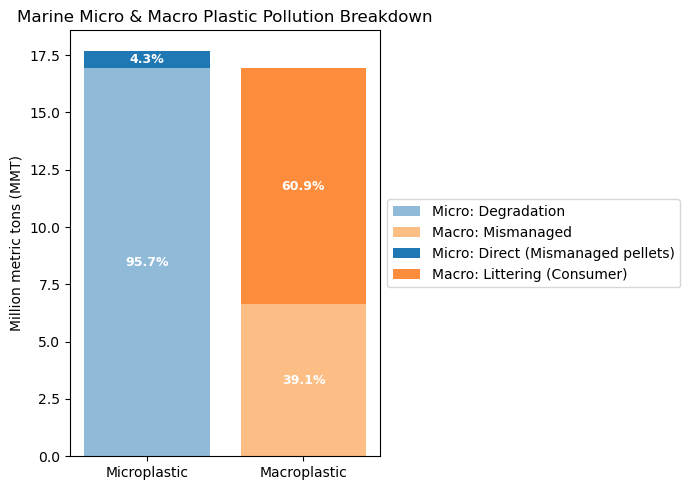

In [79]:
import matplotlib.pyplot as plt

# ---- keys from your computed dicts ----
micro_direct_key = "microplastic_direct_enable"
micro_degrad_key = "microplastic_degradation_enable"

# littering comes from the Use & Collection–only dict
macro_litter = float(
    macro_sums_mmt.get("macro_litter_enable",
                       macro_sums_mmt.get("macroplastic_enable", 0.0))  # fallback
)

# total macro comes from the all-flows dict
macro_total  = float(g_sums.get("macroplastic_enable", 0.0))

# if you also computed an explicit mismanaged key in g_sums, prefer it; otherwise derive
macro_misman = float(g_sums.get("macro_mismanage_enable", max(macro_total - macro_litter, 0.0)))

# micro parts from g_sums (already in MMT)
micro_direct = float(g_sums.get(micro_direct_key, 0.0))
micro_degrad = float(g_sums.get(micro_degrad_key, 0.0))

labels      = ["Microplastic", "Macroplastic"]
bottom_vals = [micro_degrad,   macro_misman]
top_vals    = [micro_direct,   macro_litter]

colors_bottom = ["#8FBBD9", "#FDBE85"]  # degradation, mismanaged
colors_top    = ["#1F77B4", "#FD8D3C"]  # direct/pellets, littering

x = [0, 1]
plt.figure(figsize=(7, 5))

bars_bottom = plt.bar(x, bottom_vals, color=colors_bottom)
bars_top    = plt.bar(x, top_vals, bottom=bottom_vals, color=colors_top)

# Total for each stacked bar
totals = [bottom_vals[i] + top_vals[i] for i in range(len(labels))]

# Annotate with percentages inside each bar segment
for i, bars in enumerate((bars_bottom, bars_top)):
    for j, b in enumerate(bars):
        h = b.get_height()
        if h > 0:
            share = h / totals[j] * 100
            plt.text(
                b.get_x() + b.get_width()/2,
                b.get_y() + h/2,          # halfway inside the bar segment
                f"{share:.1f}%",
                ha="center", va="center", fontsize=9, color="white", weight="bold"
            )

plt.xticks(x, labels)
plt.ylabel("Million metric tons (MMT)")
plt.title("Marine Micro & Macro Plastic Pollution Breakdown")
plt.legend(
    [bars_bottom[0], bars_bottom[1], bars_top[0], bars_top[1]],
    ["Micro: Degradation", "Macro: Mismanaged",
     "Micro: Direct (Mismanaged pellets)", "Macro: Littering (Consumer)"],
    loc="center left", bbox_to_anchor=(1.0, 0.5)
)

plt.tight_layout()
plt.show()


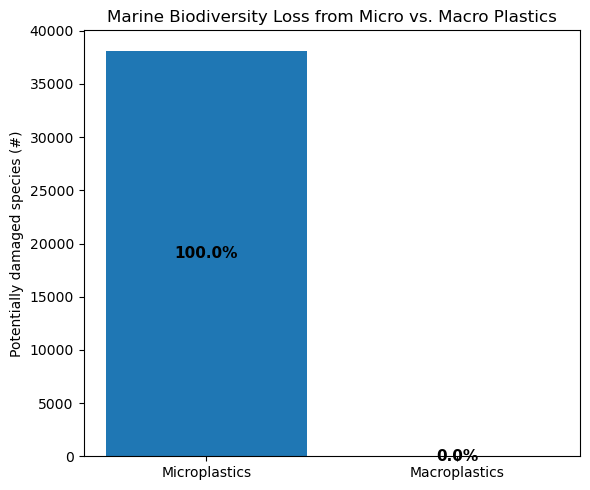

In [75]:
import matplotlib.pyplot as plt

# Example: replace with your actual computed values
# phi1_micro = ...
# phi1_macro = ...
# phi = [...]

# shares in %
share_micro = phi1_micro / phi[1] * 100 if phi[1] != 0 else 0
share_macro = phi1_macro / phi[1] * 100 if phi[1] != 0 else 0

# plot absolute numbers (species potentially damaged), but label with %
vals = [phi1_micro, phi1_macro]
labels = ["Microplastics", "Macroplastics"]
colors = ["#1F77B4", "#FD8D3C"]

plt.figure(figsize=(6,5))
bars = plt.bar(labels, vals, color=colors)

# annotate with % share inside bars
for bar, share in zip(bars, [share_micro, share_macro]):
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             h/2, f"{share:.1f}%",   # percent label
             ha="center", va="center", color="black", fontsize=11, weight="bold")

plt.ylabel("Potentially damaged species (#)")
plt.title("Marine Biodiversity Loss from Micro vs. Macro Plastics")
plt.tight_layout()
plt.show()

## Optimization

### Two-objective

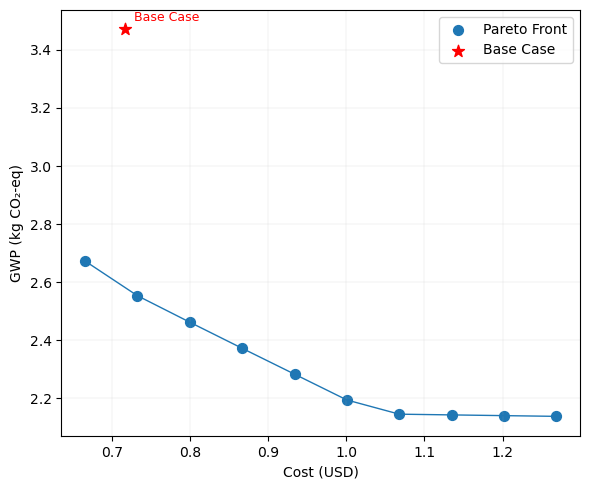

In [89]:
import numpy as np
import matplotlib.pyplot as plt

# Example input data
# Z1 = [...]  # GWP (kg CO2 eq)
# Z2 = [...]  # Cost (USD)
# names = [...]  # optional labels

Z1 = np.asarray(Z1, dtype=float)
Z2 = np.asarray(Z2, dtype=float)

# Base Case point
base_gwp = 3.47
base_cost = 0.71749

# Identify nondominated (Pareto) points (minimize both Z1, Z2)
idx = np.arange(len(Z1))
order = np.lexsort((Z1, Z2))
Z1s, Z2s, ids = Z1[order], Z2[order], idx[order]
pareto_mask = np.zeros(len(Z1s), dtype=bool)
best = np.inf
for i, z1 in enumerate(Z1s):
    if z1 < best - 1e-12:
        pareto_mask[i] = True
        best = z1
pareto_ids = ids[pareto_mask]
dominated_ids = ids[~pareto_mask]

# Plot
plt.figure(figsize=(6, 5))
if len(dominated_ids):
    plt.scatter(Z2[dominated_ids], Z1[dominated_ids], s=24, alpha=0.35, label="Dominated")
plt.scatter(Z2[pareto_ids], Z1[pareto_ids], s=50, color='tab:blue', label="Pareto Front")
p_order = np.argsort(Z2[pareto_ids])
plt.plot(Z2[pareto_ids][p_order], Z1[pareto_ids][p_order], color='tab:blue', linewidth=1)
plt.scatter(base_cost, base_gwp, color='red', s=80, marker='*', label='Base Case')
plt.annotate("Base Case", (base_cost, base_gwp), xytext=(6, 6), textcoords='offset points', fontsize=9, color='red')

plt.xlabel("Cost (USD)")
plt.ylabel("GWP (kg CO₂-eq)")
#plt.title("All but Circularity")
plt.grid(True, linewidth=0.3, alpha=0.4)
plt.legend()
plt.tight_layout()

# Export the figure
plt.savefig("pareto_front.png", dpi=600)  # high-res PNG
plt.show()

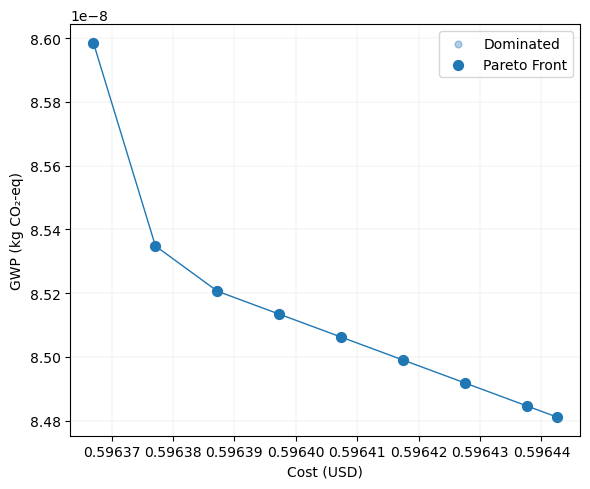

In [423]:
import numpy as np
import matplotlib.pyplot as plt

# Example input data
# Z1 = [...]  # GWP (kg CO2 eq)
# Z2 = [...]  # Cost (USD)
# names = [...]  # optional labels

Z1 = np.asarray(X1_CS1, dtype=float)
Z2 = np.asarray(X2_CS1, dtype=float)

# Base Case point
base_gwp = 8.89E-08
base_cost = 0.71749

# Identify nondominated (Pareto) points (minimize both Z1, Z2)
idx = np.arange(len(Z1))
order = np.lexsort((Z1, Z2))
Z1s, Z2s, ids = Z1[order], Z2[order], idx[order]
pareto_mask = np.zeros(len(Z1s), dtype=bool)
best = np.inf
for i, z1 in enumerate(Z1s):
    if z1 < best - 1e-12:
        pareto_mask[i] = True
        best = z1
pareto_ids = ids[pareto_mask]
dominated_ids = ids[~pareto_mask]

# Plot
plt.figure(figsize=(6, 5))
if len(dominated_ids):
    plt.scatter(Z2[dominated_ids], Z1[dominated_ids], s=24, alpha=0.35, label="Dominated")
plt.scatter(Z2[pareto_ids], Z1[pareto_ids], s=50, color='tab:blue', label="Pareto Front")
p_order = np.argsort(Z2[pareto_ids])
plt.plot(Z2[pareto_ids][p_order], Z1[pareto_ids][p_order], color='tab:blue', linewidth=1)
#plt.scatter(base_cost, base_gwp, color='red', s=80, marker='*', label='Base Case')
#plt.annotate("Base Case", (base_cost, base_gwp), xytext=(6, 6), textcoords='offset points', fontsize=9, color='red')

plt.xlabel("Cost (USD)")
plt.ylabel("GWP (kg CO₂-eq)")
#plt.title("All but Circularity")
plt.grid(True, linewidth=0.3, alpha=0.4)
plt.legend()
plt.tight_layout()

# Export the figure
plt.savefig("pareto_front.png", dpi=600)  # high-res PNG
plt.show()

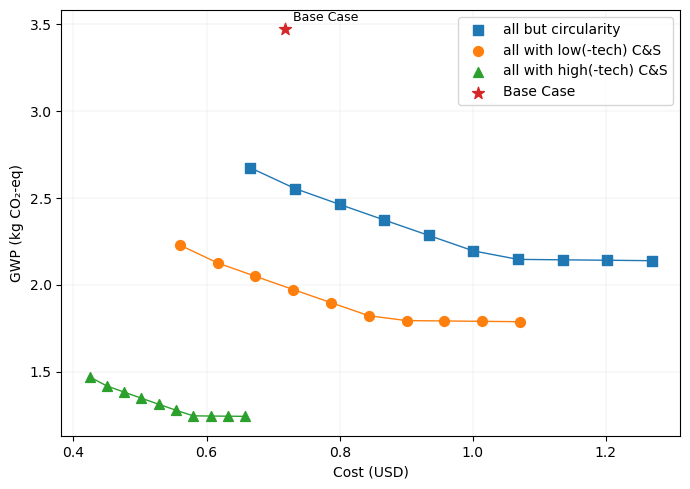

In [234]:
import numpy as np
import matplotlib.pyplot as plt

# Inputs (replace with your data)
# Z1_CS0, Z2_CS0 = [...], [...]   # all but circularity
# Z1_CS1, Z2_CS1 = [...], [...]   # all with low(-tech) C&S
# Z1_CS2, Z2_CS2 = [...], [...]   # all with high(-tech) C&S

def pareto_ids(Z1, Z2, tol=1e-12):
    Z1, Z2 = np.asarray(Z1, float), np.asarray(Z2, float)
    idx = np.arange(len(Z1))
    order = np.lexsort((Z1, Z2))        # sort by Z2 then Z1
    Z1s, Z2s, ids = Z1[order], Z2[order], idx[order]
    mask = np.zeros(len(Z1s), bool)
    best = np.inf
    for i, z1 in enumerate(Z1s):
        if z1 < best - tol:
            mask[i] = True
            best = z1
    return ids[mask], ids[~mask]

def plot_front(Z1, Z2, label, marker='o', ms=50, lw=1.0):
    Z1, Z2 = np.asarray(Z1, float), np.asarray(Z2, float)
    p_ids, d_ids = pareto_ids(Z1, Z2)
    if d_ids.size:
        plt.scatter(Z2[d_ids], Z1[d_ids], s=20, alpha=0.25)
    plt.scatter(Z2[p_ids], Z1[p_ids], s=ms, marker=marker, label=label)
    order = np.argsort(Z2[p_ids])
    plt.plot(Z2[p_ids][order], Z1[p_ids][order], linewidth=lw)

plt.figure(figsize=(7, 5))
plot_front(Z1_CS0, Z2_CS0, label="all but circularity", marker='s')
plot_front(Z1_CS1, Z2_CS1, label="all with low(-tech) C&S", marker='o')
plot_front(Z1_CS2, Z2_CS2, label="all with high(-tech) C&S", marker='^')

# Optional: add Base Case
base_gwp, base_cost = 3.47, 0.71749
plt.scatter(base_cost, base_gwp, s=80, marker='*', label='Base Case')
plt.annotate("Base Case", (base_cost, base_gwp), xytext=(6, 6), textcoords='offset points', fontsize=9)

plt.xlabel("Cost (USD)")
plt.ylabel("GWP (kg CO₂-eq)")
#plt.title("Pareto Fronts: Cost vs GWP")
plt.grid(True, linewidth=0.3, alpha=0.4)
plt.legend()
plt.tight_layout()

# Export (choose one or both)
plt.savefig("pareto_three_fronts.svg")       # vector
plt.savefig("pareto_three_fronts.png", dpi=400)  # high-res raster
plt.show()


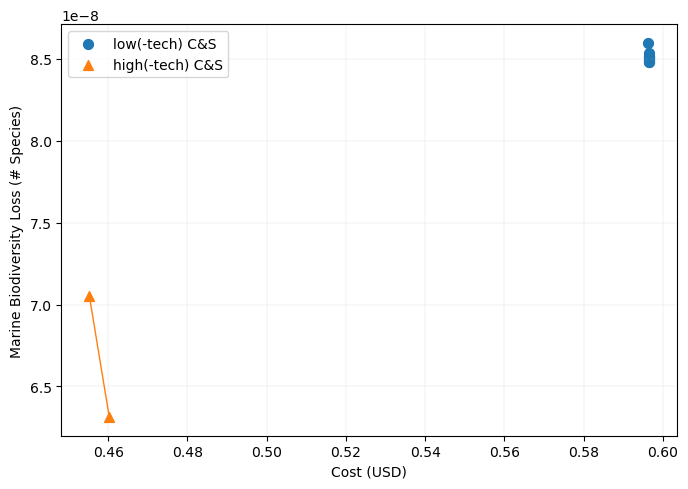

In [459]:
import numpy as np
import matplotlib.pyplot as plt

# Inputs (replace with your data)
# Z1_CS0, Z2_CS0 = [...], [...]   # all but circularity
# Z1_CS1, Z2_CS1 = [...], [...]   # all with low(-tech) C&S
# Z1_CS2, Z2_CS2 = [...], [...]   # all with high(-tech) C&S

def pareto_ids(Z1, Z2, tol=1e-12):
    Z1, Z2 = np.asarray(Z1, float), np.asarray(Z2, float)
    idx = np.arange(len(Z1))
    order = np.lexsort((Z1, Z2))        # sort by Z2 then Z1
    Z1s, Z2s, ids = Z1[order], Z2[order], idx[order]
    mask = np.zeros(len(Z1s), bool)
    best = np.inf
    for i, z1 in enumerate(Z1s):
        if z1 < best - tol:
            mask[i] = True
            best = z1
    return ids[mask], ids[~mask]

def plot_front(Z1, Z2, label, marker='o', ms=50, lw=1.0):
    Z1, Z2 = np.asarray(Z1, float), np.asarray(Z2, float)
    p_ids, d_ids = pareto_ids(Z1, Z2)
    plt.scatter(Z2[p_ids], Z1[p_ids], s=ms, marker=marker, label=label)
    order = np.argsort(Z2[p_ids])
    plt.plot(Z2[p_ids][order], Z1[p_ids][order], linewidth=lw)


plt.figure(figsize=(7, 5))
plot_front(X1_CS1, X2_CS1, label="low(-tech) C&S", marker='o')
plot_front(X1_CS2, X2_CS2, label="high(-tech) C&S", marker='^')

# Optional: add Base Case
#base_gwp, base_cost = 3.47, 0.71749
#plt.scatter(base_cost, base_gwp, s=80, marker='*', label='Base Case')
#plt.annotate("Base Case", (base_cost, base_gwp), xytext=(6, 6), textcoords='offset points', fontsize=9)

plt.xlabel("Cost (USD)")
plt.ylabel("Marine Biodiversity Loss (# Species)")
#plt.title("Pareto Fronts: Cost vs GWP")
plt.grid(True, linewidth=0.3, alpha=0.4)
plt.legend()
plt.tight_layout()

# Export (choose one or both)
plt.savefig("pareto_three_fronts.svg")       # vector
plt.savefig("pareto_three_fronts.png", dpi=400)  # high-res raster
plt.show()

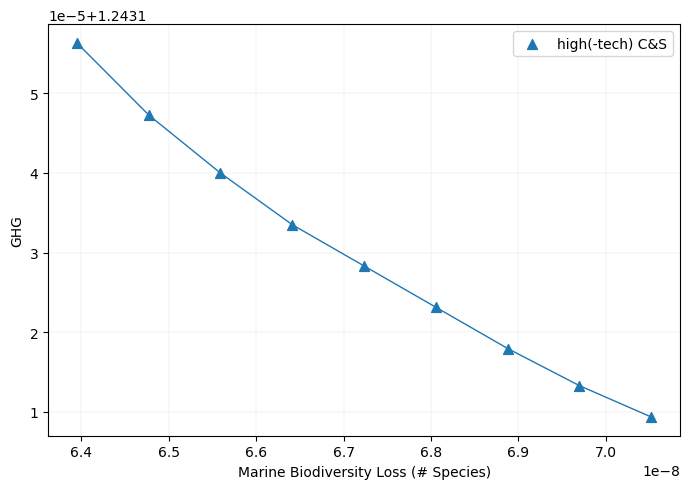

In [559]:
import numpy as np
import matplotlib.pyplot as plt

# Inputs (replace with your data)
# Z1_CS0, Z2_CS0 = [...], [...]   # all but circularity
# Z1_CS1, Z2_CS1 = [...], [...]   # all with low(-tech) C&S
# Z1_CS2, Z2_CS2 = [...], [...]   # all with high(-tech) C&S

def pareto_ids(Z1, Z2, tol=1e-12):
    Z1, Z2 = np.asarray(Z1, float), np.asarray(Z2, float)
    idx = np.arange(len(Z1))
    order = np.lexsort((Z1, Z2))        # sort by Z2 then Z1
    Z1s, Z2s, ids = Z1[order], Z2[order], idx[order]
    mask = np.zeros(len(Z1s), bool)
    best = np.inf
    for i, z1 in enumerate(Z1s):
        if z1 < best - tol:
            mask[i] = True
            best = z1
    return ids[mask], ids[~mask]

def plot_front(Z1, Z2, label, marker='o', ms=50, lw=1.0):
    Z1, Z2 = np.asarray(Z1, float), np.asarray(Z2, float)
    p_ids, d_ids = pareto_ids(Z1, Z2)
    plt.scatter(Z2[p_ids], Z1[p_ids], s=ms, marker=marker, label=label)
    order = np.argsort(Z2[p_ids])
    plt.plot(Z2[p_ids][order], Z1[p_ids][order], linewidth=lw)


plt.figure(figsize=(7, 5))
plot_front(Y1_CS2, Y2_CS2, label="high(-tech) C&S", marker='^')

# Optional: add Base Case
#base_gwp, base_cost = 3.47, 0.71749
#plt.scatter(base_cost, base_gwp, s=80, marker='*', label='Base Case')
#plt.annotate("Base Case", (base_cost, base_gwp), xytext=(6, 6), textcoords='offset points', fontsize=9)

plt.xlabel("Marine Biodiversity Loss (# Species)")
plt.ylabel("GHG")
#plt.title("Pareto Fronts: Cost vs GWP")
plt.grid(True, linewidth=0.3, alpha=0.4)
plt.legend()
plt.tight_layout()

# Export (choose one or both)
plt.savefig("pareto_three_fronts.svg")       # vector
plt.savefig("pareto_three_fronts.png", dpi=400)  # high-res raster
plt.show()

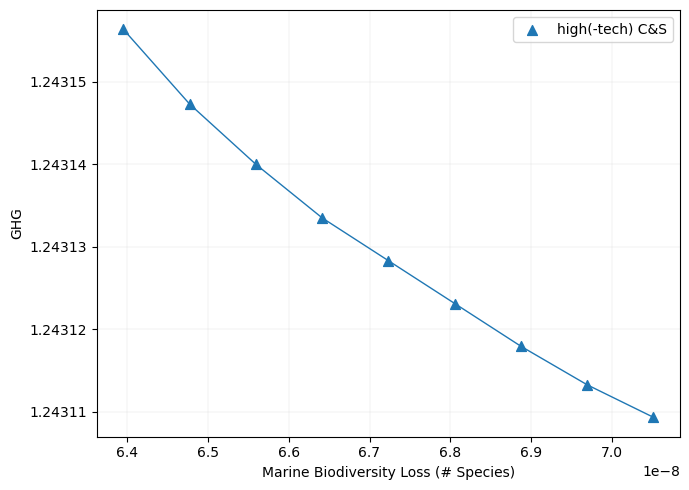

In [561]:
import numpy as np
import matplotlib.pyplot as plt

# Inputs (replace with your data)
# Y1_CS2, Y2_CS2 = [...], [...]

def pareto_ids(Z1, Z2, tol=1e-12):
    Z1, Z2 = np.asarray(Z1, float), np.asarray(Z2, float)
    idx = np.arange(len(Z1))
    order = np.lexsort((Z1, Z2))        # sort by Z2 then Z1
    Z1s, Z2s, ids = Z1[order], Z2[order], idx[order]
    mask = np.zeros(len(Z1s), bool)
    best = np.inf
    for i, z1 in enumerate(Z1s):
        if z1 < best - tol:
            mask[i] = True
            best = z1
    return ids[mask], ids[~mask]

def plot_front(Z1, Z2, label, marker='o', ms=50, lw=1.0):
    Z1, Z2 = np.asarray(Z1, float), np.asarray(Z2, float)
    p_ids, d_ids = pareto_ids(Z1, Z2)
    plt.scatter(Z2[p_ids], Z1[p_ids], s=ms, marker=marker, label=label)
    order = np.argsort(Z2[p_ids])
    plt.plot(Z2[p_ids][order], Z1[p_ids][order], linewidth=lw)

# Plot
plt.figure(figsize=(7, 5))
plot_front(Y1_CS2, Y2_CS2, label="high(-tech) C&S", marker='^')

# Optional: add Base Case
# base_gwp, base_cost = 3.47, 0.71749
# plt.scatter(base_cost, base_gwp, s=80, marker='*', label='Base Case')
# plt.annotate("Base Case", (base_cost, base_gwp), xytext=(6, 6),
#              textcoords='offset points', fontsize=9)

plt.xlabel("Marine Biodiversity Loss (# Species)")
plt.ylabel("GHG")
plt.grid(True, linewidth=0.3, alpha=0.4)
plt.legend()

# Disable scientific notation on Y-axis
plt.ticklabel_format(axis='y', style='plain', useOffset=False)

plt.tight_layout()

# Export (choose one or both)
plt.savefig("pareto_three_fronts.svg")       # vector
plt.savefig("pareto_three_fronts.png", dpi=400)  # high-res raster
plt.show()


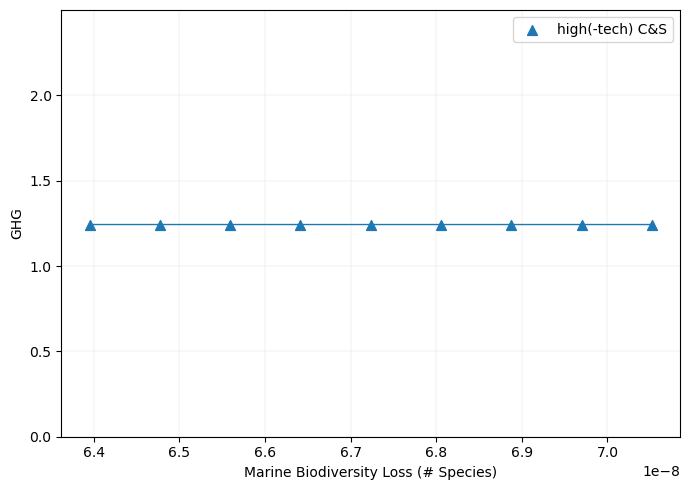

In [562]:
import numpy as np
import matplotlib.pyplot as plt

# Inputs (replace with your data)
# Y1_CS2, Y2_CS2 = [...], [...]

def pareto_ids(Z1, Z2, tol=1e-12):
    Z1, Z2 = np.asarray(Z1, float), np.asarray(Z2, float)
    idx = np.arange(len(Z1))
    order = np.lexsort((Z1, Z2))        # sort by Z2 then Z1
    Z1s, Z2s, ids = Z1[order], Z2[order], idx[order]
    mask = np.zeros(len(Z1s), bool)
    best = np.inf
    for i, z1 in enumerate(Z1s):
        if z1 < best - tol:
            mask[i] = True
            best = z1
    return ids[mask], ids[~mask]

def plot_front(Z1, Z2, label, marker='o', ms=50, lw=1.0):
    Z1, Z2 = np.asarray(Z1, float), np.asarray(Z2, float)
    p_ids, d_ids = pareto_ids(Z1, Z2)
    plt.scatter(Z2[p_ids], Z1[p_ids], s=ms, marker=marker, label=label)
    order = np.argsort(Z2[p_ids])
    plt.plot(Z2[p_ids][order], Z1[p_ids][order], linewidth=lw)

# Plot
plt.figure(figsize=(7, 5))
plot_front(Y1_CS2, Y2_CS2, label="high(-tech) C&S", marker='^')

# Optional: add Base Case
# base_gwp, base_cost = 3.47, 0.71749
# plt.scatter(base_cost, base_gwp, s=80, marker='*', label='Base Case')
# plt.annotate("Base Case", (base_cost, base_gwp), xytext=(6, 6),
#              textcoords='offset points', fontsize=9)

plt.xlabel("Marine Biodiversity Loss (# Species)")
plt.ylabel("GHG")
plt.grid(True, linewidth=0.3, alpha=0.4)
plt.legend()

# Force normal y-axis scaling with 0.5 intervals
plt.yticks(np.arange(0, np.ceil(max(Y1_CS2)) + 0.5, 0.5))
plt.ylim(0, np.ceil(max(Y1_CS2)) + 0.5)

plt.ticklabel_format(axis='y', style='plain', useOffset=False)
plt.tight_layout()

# Export
plt.savefig("pareto_three_fronts.svg")       # vector
plt.savefig("pareto_three_fronts.png", dpi=400)  # high-res raster
plt.show()


In [294]:
(Z1_CS0[0]-3.47)/3.47

-0.22971749674454642

In [297]:
(Z2_CS0[0]-0.71749)/0.71749

-0.0720961613047855

In [298]:
(Z1_CS0[9]-3.47)/3.47

-0.3837130822489067

In [299]:
(Z2_CS0[9]-0.71749)/0.71749

0.7686175467583957

In [300]:
(Z1_CS1[0]-3.47)/3.47

-0.35791727822014924

In [301]:
(Z2_CS1[0]-0.71749)/0.71749

-0.21950614997633394

In [332]:
(Z1_CS1[9]-3.47)/3.47

-0.4848556341313201

In [333]:
(Z2_CS1[9]-0.71749)/0.71749

0.49215944493587477

In [334]:
(Z1_CS2[0]-3.47)/3.47

-0.5762279534786947

In [335]:
(Z2_CS2[0]-0.71749)/0.71749

-0.408789483023213

In [336]:
(Z1_CS2[9]-3.47)/3.47

-0.641755233798143

In [337]:
(Z2_CS2[9]-0.71749)/0.71749

-0.08293134767551393

### Multi-objective

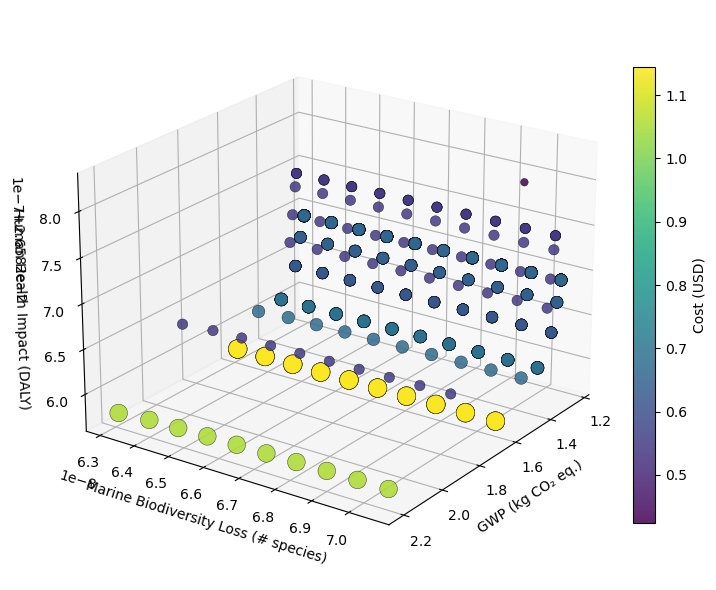

In [603]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)
from matplotlib.colors import Normalize

# ---- inputs (replace with your arrays of equal length) ----
# Z1 = ...  # GWP (kg CO2 eq)  -> x
# Z2 = ...  # Marine Biodiversity Loss (# species) -> y
# Z3 = ...  # Human Health Impact (DALY) -> z
# Z4 = ...  # Cost (USD) -> color & size
Z1 = np.asarray(Z1, float)
Z2 = np.asarray(Z2, float)
Z3 = np.asarray(Z3, float)
Z4 = np.asarray(Z4, float)

# Optional: base case
# base = {"x": 3.47, "y": <biodiv>, "z": <DALY>, "cost": 0.71749}

# ---- clean NaNs/Infs consistently ----
mask = np.isfinite(Z1) & np.isfinite(Z2) & np.isfinite(Z3) & np.isfinite(Z4)
Z1, Z2, Z3, Z4 = Z1[mask], Z2[mask], Z3[mask], Z4[mask]

# ---- size scaling from cost (Z4) ----
# tweak these if the points look too small/large
size_min, size_max = 30.0, 180.0
if np.allclose(Z4.max(), Z4.min()):
    sizes = np.full_like(Z4, (size_min + size_max) / 2.0)
    norm = Normalize(vmin=Z4.min() - 1e-9, vmax=Z4.max() + 1e-9)
else:
    norm = Normalize(vmin=Z4.min(), vmax=Z4.max())
    sizes = size_min + (Z4 - Z4.min()) / (Z4.max() - Z4.min()) * (size_max - size_min)

# ---- plot ----
fig = plt.figure(figsize=(7.5, 6.0))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    Z1, Z2, Z3,
    c=Z4, s=sizes, cmap='viridis', alpha=0.85, depthshade=False, edgecolor='k', linewidth=0.3
)

# Optional: plot base case as a star
# if base:
#     ax.scatter(base["x"], base["y"], base["z"], s=220, marker='*', c=[base["cost"]],
#                cmap='viridis', norm=norm, edgecolor='k', linewidth=0.6, label='Base Case')

# axes labels
ax.set_xlabel("GWP (kg CO₂ eq.)")
ax.set_ylabel("Marine Biodiversity Loss (# species)")
ax.set_zlabel("Human Health Impact (DALY)")

# colorbar for cost
cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label("Cost (USD)")

# tidy view
ax.view_init(elev=22, azim=35)  # adjust angle if needed
ax.grid(True)
plt.tight_layout()

# export
plt.savefig("pareto_4D_scatter.svg")               # vector
plt.savefig("pareto_4D_scatter.png", dpi=450)      # high-res raster
plt.show()

# ---- Optional: size legend for cost buckets ----
# If you want an explicit size legend, add a few proxies:
# import matplotlib.lines as mlines
# import matplotlib as mpl
# for val in np.linspace(Z4.min(), Z4.max(), 3):
#     s = size_min + (val - Z4.min())/(Z4.max()-Z4.min()+1e-12) * (size_max-size_min)
#     ax.scatter([], [], [], s=s, c='none', edgecolor='k', label=f"${val:,.2f}")
# ax.legend(title="Cost (size)", loc="upper left", bbox_to_anchor=(1.02, 1.0))
# plt.tight_layout()


In [604]:
import numpy as np

Z1 = np.array(Z1)
Z2 = np.array(Z2)
Z3 = np.array(Z3)
Z4 = np.array(Z4)

# normalize all objectives to [0,1] to avoid scale bias
Z1n = (Z1 - Z1.min()) / (Z1.max() - Z1.min() + 1e-12)
Z2n = (Z2 - Z2.min()) / (Z2.max() - Z2.min() + 1e-12)
Z3n = (Z3 - Z3.min()) / (Z3.max() - Z3.min() + 1e-12)
Z4n = (Z4 - Z4.min()) / (Z4.max() - Z4.min() + 1e-12)

dist = np.sqrt(Z1n**2 + Z2n**2 + Z3n**2 + Z4n**2)
best_idx = np.argmin(dist)

print(f"Best (closest-to-ideal) solution index: {best_idx}")
print(f"GWP={Z1[best_idx]:.4f}, Marine={Z2[best_idx]:.4e}, Health={Z3[best_idx]:.4e}, Cost={Z4[best_idx]:.4f}")


Best (closest-to-ideal) solution index: 14
GWP=1.2929, Marine=6.3129e-08, Health=2.6583e-02, Cost=0.6207


Best solution index: 14
GWP=1.2929, Marine=6.3129e-08, Health=2.6583e-02, Cost=0.6207


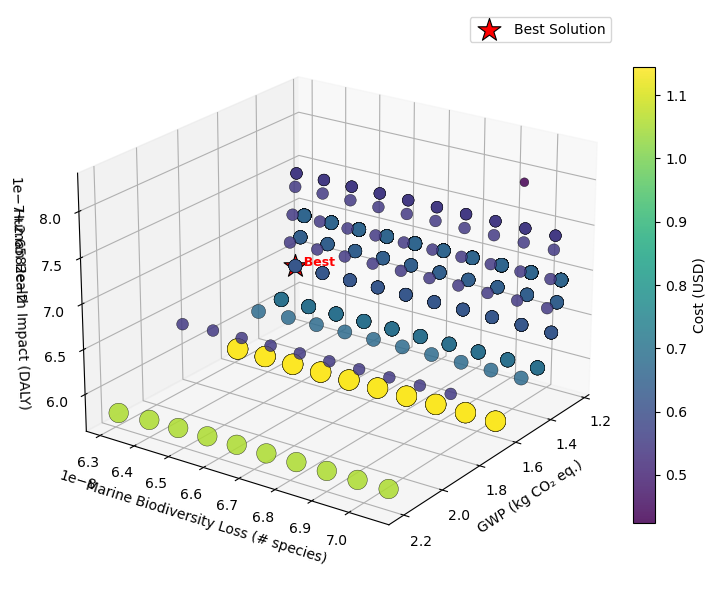

In [605]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize

# Assume Z1..Z4 are already defined
Z1, Z2, Z3, Z4 = map(np.asarray, (Z1, Z2, Z3, Z4))

# --- find the best (closest to ideal) solution ---
Z1n = (Z1 - Z1.min()) / (Z1.max() - Z1.min() + 1e-12)
Z2n = (Z2 - Z2.min()) / (Z2.max() - Z2.min() + 1e-12)
Z3n = (Z3 - Z3.min()) / (Z3.max() - Z3.min() + 1e-12)
Z4n = (Z4 - Z4.min()) / (Z4.max() - Z4.min() + 1e-12)
dist = np.sqrt(Z1n**2 + Z2n**2 + Z3n**2 + Z4n**2)
best_idx = np.argmin(dist)

print(f"Best solution index: {best_idx}")
print(f"GWP={Z1[best_idx]:.4f}, Marine={Z2[best_idx]:.4e}, "
      f"Health={Z3[best_idx]:.4e}, Cost={Z4[best_idx]:.4f}")

# --- 4D scatter visualization ---
norm = Normalize(vmin=Z4.min(), vmax=Z4.max())
sizes = 40 + 180 * (Z4 - Z4.min()) / (Z4.max() - Z4.min() + 1e-12)

fig = plt.figure(figsize=(7.5, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(Z1, Z2, Z3, c=Z4, s=sizes, cmap="viridis",
                alpha=0.85, depthshade=False, edgecolor='k', linewidth=0.3)

# highlight best solution
ax.scatter(Z1[best_idx], Z2[best_idx], Z3[best_idx],
           s=300, c='red', marker='*', edgecolor='k', linewidth=0.8,
           label='Best Solution')
ax.text(Z1[best_idx], Z2[best_idx], Z3[best_idx],
        "  Best", color='red', fontsize=9, weight='bold')

# axes and colorbar
ax.set_xlabel("GWP (kg CO₂ eq.)")
ax.set_ylabel("Marine Biodiversity Loss (# species)")
ax.set_zlabel("Human Health Impact (DALY)")
cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label("Cost (USD)")

ax.view_init(elev=22, azim=35)
ax.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("pareto_4D_best.svg")
plt.savefig("pareto_4D_best.png", dpi=450)
plt.show()


Best solution index: 14
GWP=1.2929, Bio=6.313e-08, Health=2.658e-02, Cost=0.6207


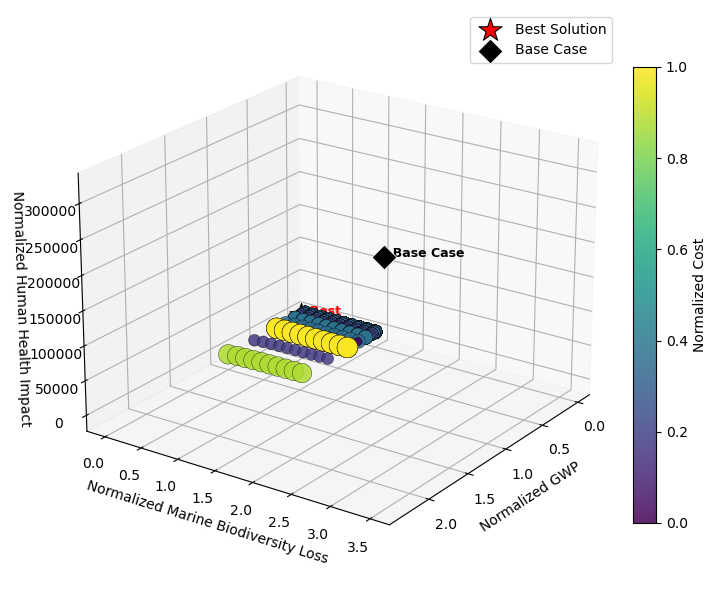

In [606]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize

# --- Input data ---
# Replace with your results
# Z1: GWP (kg CO2 eq), Z2: Marine biodiversity loss (# species),
# Z3: Human health (DALY), Z4: Cost (USD)
Z1 = np.asarray(Z1, float)
Z2 = np.asarray(Z2, float)
Z3 = np.asarray(Z3, float)
Z4 = np.asarray(Z4, float)

# Base case values
base = {
    "GWP": 3.47,
    "Bio": 8.89e-08,
    "Health": 1.05e-01,
    "Cost": 0.71749,
}

# --- Normalize all axes to [0,1] ---
def normalize(v):
    return (v - v.min()) / (v.max() - v.min() + 1e-12)

Z1n, Z2n, Z3n, Z4n = map(normalize, [Z1, Z2, Z3, Z4])

# normalize base case with same scaling
base_n = {
    "GWP": (base["GWP"] - Z1.min()) / (Z1.max() - Z1.min() + 1e-12),
    "Bio": (base["Bio"] - Z2.min()) / (Z2.max() - Z2.min() + 1e-12),
    "Health": (base["Health"] - Z3.min()) / (Z3.max() - Z3.min() + 1e-12),
    "Cost": (base["Cost"] - Z4.min()) / (Z4.max() - Z4.min() + 1e-12),
}

# --- Find best (closest to ideal) solution ---
dist = np.sqrt(Z1n**2 + Z2n**2 + Z3n**2 + Z4n**2)
best_idx = np.argmin(dist)
print(f"Best solution index: {best_idx}")
print(f"GWP={Z1[best_idx]:.4f}, Bio={Z2[best_idx]:.3e}, Health={Z3[best_idx]:.3e}, Cost={Z4[best_idx]:.4f}")

# --- Size and color by cost ---
norm = Normalize(vmin=Z4n.min(), vmax=Z4n.max())
sizes = 40 + 180 * Z4n

# --- 3D scatter plot (normalized axes) ---
fig = plt.figure(figsize=(7.5, 6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(Z1n, Z2n, Z3n, c=Z4n, s=sizes, cmap='viridis',
                alpha=0.85, depthshade=False, edgecolor='k', linewidth=0.3)

# Highlight best (red star)
ax.scatter(Z1n[best_idx], Z2n[best_idx], Z3n[best_idx],
           s=300, c='red', marker='*', edgecolor='k', linewidth=0.8, label='Best Solution')
ax.text(Z1n[best_idx], Z2n[best_idx], Z3n[best_idx],
        "  Best", color='red', fontsize=9, weight='bold')

# Show base case (black diamond)
ax.scatter(base_n["GWP"], base_n["Bio"], base_n["Health"],
           s=160, c='black', marker='D', edgecolor='white', linewidth=0.6, label='Base Case')
ax.text(base_n["GWP"], base_n["Bio"], base_n["Health"],
        "  Base Case", color='black', fontsize=9, weight='bold')

# --- Labels and colorbar ---
ax.set_xlabel("Normalized GWP")
ax.set_ylabel("Normalized Marine Biodiversity Loss")
ax.set_zlabel("Normalized Human Health Impact")
cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label("Normalized Cost")

ax.view_init(elev=22, azim=35)
ax.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("pareto_4D_normalized_best_base.svg")
plt.savefig("pareto_4D_normalized_best_base.png", dpi=450)
plt.show()


Best solution index: 14
GWP=1.2929, Bio=6.313e-08, Health=2.658e-02, Cost=0.6207


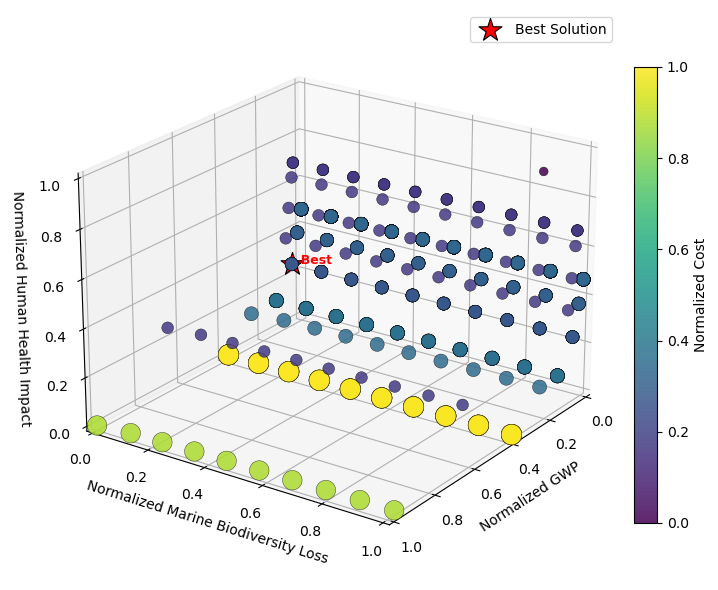

In [611]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize

# --- Input data ---
# Z1: GWP (kg CO2 eq)
# Z2: Marine Biodiversity Loss (# species)
# Z3: Human Health Impact (DALY)
# Z4: Cost (USD)
Z1 = np.asarray(Z1, float)
Z2 = np.asarray(Z2, float)
Z3 = np.asarray(Z3, float)
Z4 = np.asarray(Z4, float)

# Base case values
base = {
    "GWP": 3.47,
    "Bio": 8.89e-08,
    "Health": 1.05e-01,
    "Cost": 0.71749,
}

# --- Normalize all objectives to [0, 1] ---
def normalize(v, ref=None):
    vmin, vmax = v.min(), v.max()
    return (v - vmin) / (vmax - vmin + 1e-12), (ref - vmin) / (vmax - vmin + 1e-12) if ref is not None else None

Z1n, base_gwp_n = normalize(Z1, base["GWP"])
Z2n, base_bio_n = normalize(Z2, base["Bio"])
Z3n, base_hh_n  = normalize(Z3, base["Health"])
Z4n, base_cost_n = normalize(Z4, base["Cost"])

# --- Find best (closest-to-ideal) solution ---
dist = np.sqrt(Z1n**2 + Z2n**2 + Z3n**2 + Z4n**2)
best_idx = np.argmin(dist)
print(f"Best solution index: {best_idx}")
print(f"GWP={Z1[best_idx]:.4f}, Bio={Z2[best_idx]:.3e}, Health={Z3[best_idx]:.3e}, Cost={Z4[best_idx]:.4f}")

# --- Size and color by cost ---
norm = Normalize(vmin=Z4n.min(), vmax=Z4n.max())
sizes = 40 + 180 * Z4n

# --- 3D scatter (normalized) ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    Z1n, Z2n, Z3n,
    c=Z4n, s=sizes,
    cmap="viridis", alpha=0.85,
    edgecolor="k", linewidth=0.3
)

# Highlight best (red star)
ax.scatter(Z1n[best_idx], Z2n[best_idx], Z3n[best_idx],
           s=300, c="red", marker="*", edgecolor="k", linewidth=0.8, label="Best Solution")
ax.text(Z1n[best_idx], Z2n[best_idx], Z3n[best_idx],
        "  Best", color="red", fontsize=9, weight="bold")

# Show base case (black diamond)
#ax.scatter(base_gwp_n, base_bio_n, base_hh_n,
           #s=160, c="black", marker="D", edgecolor="white", linewidth=0.6, label="Base Case")
#ax.text(base_gwp_n, base_bio_n, base_hh_n,
        #"  Base Case", color="black", fontsize=9, weight="bold")

# --- Labels, limits, and colorbar ---
ax.set_xlabel("Normalized GWP")
ax.set_ylabel("Normalized Marine Biodiversity Loss")
ax.set_zlabel("Normalized Human Health Impact")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)

cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label("Normalized Cost")

ax.view_init(elev=22, azim=35)
ax.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("pareto_4D_normalized_axes.svg")
plt.savefig("pareto_4D_normalized_axes.png", dpi=450)
plt.show()


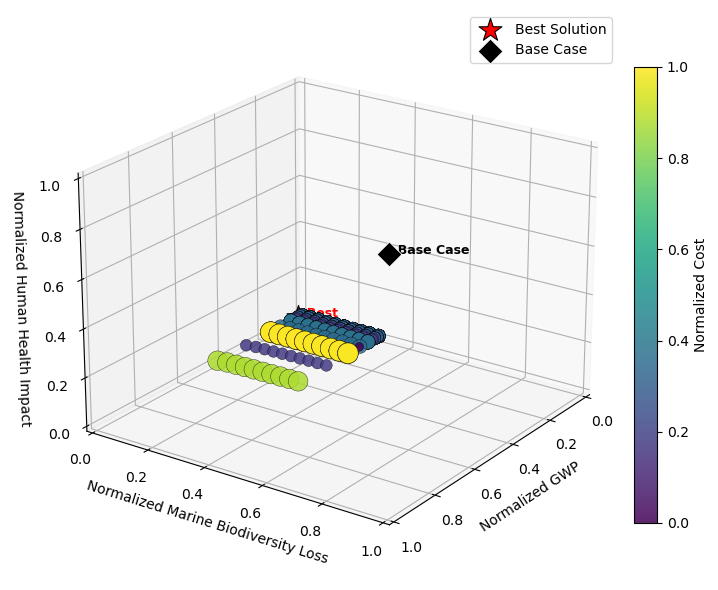

In [608]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize

# Inputs (arrays of equal length)
Z1 = np.asarray(Z1, float)  # GWP
Z2 = np.asarray(Z2, float)  # Marine biodiversity loss
Z3 = np.asarray(Z3, float)  # Human health (DALY)
Z4 = np.asarray(Z4, float)  # Cost

# Base case (must be included in normalization)
base = {"GWP": 3.47, "Bio": 8.89e-08, "Health": 1.05e-01, "Cost": 0.71749}

def norm_with_base(vec, base_val):
    aug = np.append(vec, base_val)
    vmin, vmax = aug.min(), aug.max()
    aug_n = (aug - vmin) / (vmax - vmin + 1e-12)
    return aug_n[:-1], float(aug_n[-1])

Z1n, base_gwp_n = norm_with_base(Z1, base["GWP"])
Z2n, base_bio_n = norm_with_base(Z2, base["Bio"])
Z3n, base_hh_n  = norm_with_base(Z3, base["Health"])
Z4n, base_cost_n = norm_with_base(Z4, base["Cost"])

# Best (closest to ideal [0,0,0,0]) using normalized objectives
dist = np.sqrt(Z1n**2 + Z2n**2 + Z3n**2 + Z4n**2)
best_idx = np.argmin(dist)

# Size/color by normalized cost
sizes = 40 + 180 * Z4n
norm = Normalize(vmin=0.0, vmax=1.0)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(Z1n, Z2n, Z3n, c=Z4n, s=sizes, cmap="viridis",
                alpha=0.85, edgecolor="k", linewidth=0.3)

# Highlight best solution
ax.scatter(Z1n[best_idx], Z2n[best_idx], Z3n[best_idx],
           s=300, c="red", marker="*", edgecolor="k", linewidth=0.8, label="Best Solution")
ax.text(Z1n[best_idx], Z2n[best_idx], Z3n[best_idx], "  Best", color="red", fontsize=9, weight="bold")

# Plot base case (normalized with same scale)
ax.scatter(base_gwp_n, base_bio_n, base_hh_n,
           s=160, c="black", marker="D", edgecolor="white", linewidth=0.6, label="Base Case")
ax.text(base_gwp_n, base_bio_n, base_hh_n, "  Base Case", color="black", fontsize=9, weight="bold")

# Axes strictly 0..1
ax.set_xlabel("Normalized GWP")
ax.set_ylabel("Normalized Marine Biodiversity Loss")
ax.set_zlabel("Normalized Human Health Impact")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_zlim(0, 1)

# Colorbar (normalized cost 0..1)
cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label("Normalized Cost")

ax.view_init(elev=22, azim=35)
ax.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("pareto_4D_normalized_including_base.svg")
plt.savefig("pareto_4D_normalized_including_base.png", dpi=450)
plt.show()
